# Agente com fluxos diferentes

In [1]:
import sys
sys.path.append("..")
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from agente_investimento import ChatAnaliseTecnica,  ChatSentimento, ChatValuation, ChatFundamentalistas 
from agente_investimento import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas
from agente_investimento import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from selenium import webdriver
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    api_key=api_key,
    #model="qwen-2.5-coder-32b",
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    # RETIRE THE TICKER DO PROMPT INITIAL
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: str  
    
    
class ModeloAnaliseTecnica():
    def __init__(
        self,
        state: State,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = ChatAnaliseTecnica(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response

class ModeloValuation:
    def __init__(
        self,
        state:State,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = ChatValuation(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )

        return response
    

class ModeloSentimento:
    def __init__(
        self,
        state:State,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = ChatSentimento(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response


class ModeloFundamentos:
    def __init__(
        self,
        state: State,
        stream: bool = False,
        modelo_llm: str = "deepseek-r1-distill-llama-70b",
        dados_inicio: str = "2021-01-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        messages = state.get('messages', [])
    
        # Verifica se há mensagens
        if not messages:
            raise ValueError("Nenhuma mensagem encontrada no estado")
        
        # Encontra a última mensagem do usuário
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        
        if not user_messages:
            raise ValueError("Nenhuma mensagem do usuário encontrada no estado")
        
        # Pega a última mensagem do usuário
        last_message = user_messages[-1]
        
        self.query = last_message.content
        
        self.ticker = state.get('ticker')
        if not self.ticker:
            raise ValueError("Ticker não encontrado no estado")
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    def dados_fundamentalistas(self) -> List[Any]:
        return tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = self.dados_fundamentalistas()
        response = ChatFundamentalistas(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        return response


def process_technical(state: State) -> State:
    try:
        modelo = ModeloAnaliseTecnica(state=state)
        response = modelo.chat_analise_tecnica()
        new_state = state.copy()
        new_state["messages"].append(AIMessage(content=response)) 
        return new_state
    except Exception as e:
        print(f"Erro no processamento de analise tecnica: {str(e)}")
        pass
    

def process_valuation(state: State) -> State:
    """
    Processa a análise de valuation e atualiza o estado.
    """
    try:
        modelo = ModeloValuation(state=state)
        response = modelo.chat_valuation()
        
        # Criar novo estado com as atualizações
        new_state = state.copy()
        
        # Adicionar a resposta ao histórico de mensagens
        new_state["messages"] = list(state["messages"])
        new_state["messages"].append(AIMessage(content=response))
        
        return new_state
        
    except Exception as e:
        print(f"Erro no processamento de analise de valuation: {str(e)}")
        pass
    
def process_sentimetal(state: State) -> State:
    try:
        modelo = ModeloSentimento(state=state)
        response= modelo.chat_sentimento()
        
        new_state = state.copy()
        new_state["messages"] = list(state["messages"])
        new_state["messages"].append(AIMessage(content=response))
        
        return new_state
    except Exception as e:
        print(f"Erro no processamento de analise de sentimento: {str(e)}")
        pass
    
def process_fundamental(state: State) -> State:
    try:
        modelo = ModeloFundamentos(state=state)
        response = modelo.chat_fundamentalistas()
        next_state = state.copy()
        next_state["messages"] = list(state["messages"])
        next_state["messages"].append(AIMessage(content=response))
        return next_state
    except Exception as e:
        print(f"Erro no processamento de fundamentos: {str(e)}")
        pass
    
    
def pegando_empresa_ticker():
    dados_empresas =  pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    empresas = dados_empresas['Empresa'].tolist()
    tickers = dados_empresas['tic'].tolist()
    
    return empresas, tickers
    
def chat_input(state: State) -> State:
    # Carrega dados das empresas
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    # Template do prompt
    prompt = """
    Você é um assistente especializado em investimentos. Por favor, extraia as seguintes informações da mensagem do usuário:
    1. O ticker (código) da ação
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical)
    3. Se não houver o método, retorne chatbot para continuar a conversa
    4. Se não houver o ticker, mas tiver o nome da empresa, procure no {empresas_tickers} o ticker correspondente ao nome da empresa
    
    Responda apenas com o ticker e o método no formato:
    TICKER: <ticker>
    MÉTODO: <método>
    """
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    
    # Fazer a chamada ao LLM
    response = llm.invoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    
    ticker = ''
    metodo_analise = ''
    
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()   
        
    if ticker and ticker not in empresas_df['tic'].to_list():
        ticker = ""
    
    # Update state
    state['ticker'] = ticker
    state['method_analysis'] = metodo_analise
    
    return state

def should_continue(state: State):
    if state["method_analysis"] == "technical":
        return 'technical'
    if state['method_analysis'] == 'valuation':
        return 'valuation'
    if state['method_analysis'] == 'sentimental':
        return 'sentimental'
    if state['method_analysis'] == "fundamentals" :
        return "fundamentals"
    return "chatbot"

graph_builder = StateGraph(State)

def chatbot(state: State) -> dict:
    """
    Processa as mensagens do usuário e retorna uma resposta formatada.
    """
    try:
        # Criar o prompt do sistema
        system_message = SystemMessage(content="""
        Você é um assistente especializado em análise de investimentos.
        Ajude o usuário com análises e informações sobre investimentos.
        Se não for perguntado nada de investimentos, volte ao chatbot e converse normalmente.
        
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        # Fazer a chamada ao LLM
        response = llm.invoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
 
        }
        
memory = MemorySaver()

graph_builder.add_node("chat_input", chat_input)
graph_builder.add_node("technical", process_technical)
graph_builder.add_node('valuation', process_valuation)
graph_builder.add_node('sentimental', process_sentimetal)
graph_builder.add_node('fundamentals', process_fundamental)

graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chat_input")
graph_builder.add_conditional_edges(
    "chat_input",
    should_continue,
    {
        "technical": "technical",
        "valuation":"valuation",
        "sentimental":"sentimental",
        "fundamentals":"fundamentals",
        "chatbot": "chatbot",        
    },
)

#graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("technical",END)
graph_builder.add_edge("valuation",END)
graph_builder.add_edge("sentimental", END)
graph_builder.add_edge("fundamentals", END)
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(checkpointer=memory)

USER_AGENT environment variable not set, consider setting it to identify your requests.


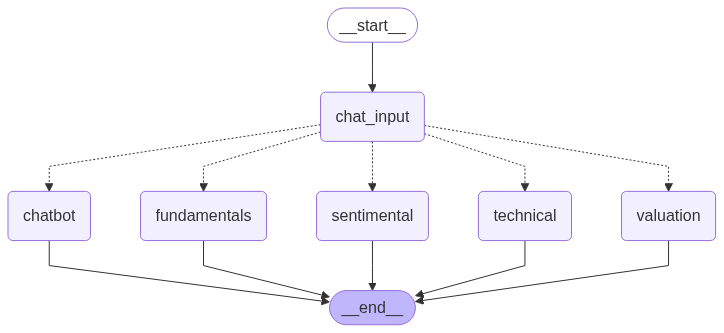

In [2]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [13]:

user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    initial_state = {
            "messages": [HumanMessage(content=mess)],
            "ticker": "",  # Definindo o ticker explicitamente
            "method_analysis": "" , # Definindo o método de análise|
            
        }
    events = graph.invoke(
            initial_state,
            config=config,
            stream_mode="values",
        )
    
    

Error fetching URL: Client error '403 Forbidden' for url 'https://conteudos.xpi.com.br/acoes/relatorios/unifique-fiqe3-resultados-em-linha-com-eps-acima-do-esperado/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: Client error '403 Forbidden' for url 'https://conteudos.xpi.com.br/acoes/relatorios/isps-tecpar-deal-macquarie/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: The read operation timed out
Error fetching URL: Client error '403 Forbidden' for url 'https://conteudos.xpi.com.br/acoes/relatorios/multiplan-mult3-manutencao-de-um-crescimento-resiliente-em-meio-a-cenarios-de-mercado-variados/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: The read operation timed out
Error fetching URL: Client error '403 Forbidden' for url 'https://conteudos.xpi.com.br/acoes/relatorios/petz-petz3-resultados-do-1t-fr

[*********************100%***********************]  1 of 1 completed


Nao tem returnOnEquity
Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: nan%


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -170.61%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [15]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================== Ai Message ==================================

Bom dia! Estou bem, obrigado por perguntar! Estou aqui para ajudar com análises e informações sobre investimentos. Qual é o seu interesse? Você está procurando por informações sobre um investimento específico, ou gostaria de saber mais sobre um tipo de investimento em particular?

================================ Human Message =================================

Olá, poderia me ajudar?

================================== Ai Message ==================================

Olá! Estou aqui para ajudar com informações e análises sobre investimentos. Qual é o seu objetivo ou dúvida relacionada a investimentos? Você está procurando por informações sobre um tipo específico de investimento, como ações, fundos, ETFs ou imóveis? Ou talvez você tenha uma carteira de investimentos e precise de ajuda para otimizá-la? Esto

# Colocando lista

In [3]:
from langchain_core.prompts import PromptTemplate

class Prompts:
    def prompt_analysis_tecnica(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=["query", "dados"],
        template="""
            
            You are a technical analyst specialized in interpreting financial indicators to identify market trends, entry, and exit points. Use the following technical data to provide a detailed analysis of the current asset situation and a possible trading strategy:

            Available Indicators:
            Moving Averages
            20 periods:
            100 periods:
            200 periods:
            Relative Strength Index (RSI - 14 periods)
            MACD and Signal Line:
            MACD:
            Signal:
            Bollinger Bands:
            Upper:
            Middle:
            Lower:
            Support and Resistance Levels (Pivot Points):
            Pivot Point:
            Supports:
            Resistances:
            VWAP (Volume Weighted Average Price)
            ADX (Average Directional Index - 14 periods)
            Analysis Objectives:
            Trend Identification:
            Is the price above or below the moving averages?
            Do the moving averages indicate an uptrend or downtrend?
            Does the ADX indicate a strong trend (>25) or a weak trend (<25)?
            Market Strength:
            Does the RSI suggest overbought conditions (>70) or oversold conditions (<30)?
            Is the MACD crossing the signal line, suggesting a potential entry/exit point?
            Support and Resistance:
            Is the current price near a significant support or resistance level?
            Do the Bollinger Bands indicate high volatility (expansion) or low volatility (contraction)?
            Possible Strategy:
            If in an uptrend: Identify buying points and profit targets.
            If in a downtrend: Identify selling points and downside targets.
            If in a ranging market: Suggest reversal or breakout strategies.
            Based on these factors, provide a detailed analysis of the current asset situation and a recommended course of action (buy, sell, or wait).
            .  

                                                                                                            
            REQUESTED ANALYSIS:
            Question: {query}
            Financial Data: {dados}
            
            
            Always response the questions in Portuguese.

        """,
    )
        return prompt
    
    def prompt_analise_sentimento(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=["query", "noticias"],
        template="""
          You are an investment analyst specializing in Natural Language Processing (NLP). Your task is to evaluate the overall sentiment of recent news about a specific company and determine whether the current outlook is positive or negative for investment."

        📌 Model Input:
        A set of recent news articles about the company [COMPANY_NAME] collected from the internet.
        The news may include headlines, summaries, or full articles.
        
        Expected Output:
        1Sentiment Analysis
        For each news article, determine the predominant sentiment:
        Positive → Growth indicators, strong financial results, innovations, strategic acquisitions.
        Neutral → News with no direct impact or mixed information.
        Negative → Scandals, market declines, financial issues, internal crises.
        
        Assign a sentiment score (e.g., from -1 to +1).
        
        Overall Sentiment Score Calculation
        Based on the analyzed news, calculate an average sentiment index:
        Index ≥ +0.3 → Positive investment outlook.
        Index between -0.3 and +0.3 → Neutral outlook, caution advised.
        Index ≤ -0.3 → Negative outlook, not a good time to invest.
        
        Conclusion & Recommendation
        Is it a good time to invest?
        YES, positive outlook: Overall sentiment is favorable, and the company has good prospects.
        CAUTION, mixed outlook: There are uncertainties or market volatility.
        NO, negative outlook: Many negative news stories indicate high risk.     
                                                    
                                                                                                   
        REQUESTED ANALYSIS:
        Question: {query}
        Financial New Data: {noticia}
        
        Always response the questions in Portuguese.

      """,
    )
        return prompt
    def prompt_analise_fundamentalista(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=["query", "dados"],
        template="""
                You are a fundamental analyst, responsible for assessing the financial health, operational performance, and investment prospects of companies based on financial indicators. Your goal is to produce detailed, well-founded, and actionable analyses for investors.

                The indicators you receive include the following data:

                Resultados financeiros: receita_liquida, resultado_bruto, ebit, ebitda, lucro_liquido, lucro_por_acao.
                Fluxos de caixa: fluxo_caixa_operacional, fluxo_caixa_investimentos, fluxo_caixa_financiamento, fluxo_caixa_livre_tres_meses.
                Investimentos e despesas: capex_tres_meses.
                Valuation: preço_lucro, preço_receita_líquida,  preço_fcf, preço_ebit, ev_ebit, ev_ebitda, enterprise_value, market_cap_empresa.
                Dividendo: dividend_yield.
                Balanço patrimonial: ativo_total, divida_bruta, divida_liquida, patrimonio_liquido, valor_patrimonial_acao.
                Indicadores de rentabilidade e eficiência: retorno_sobre_capital_tangivel_inicial, retorno_sobre_capital_investido_inicial, retorno_sobre_patrimonio_liquido_inicial, margem_bruta, margem_liquida, giro_do_ativo_inicial, alavancagem_financeira.
                Riscos e alavancagem:  passivo_patrimonio_liquido.
                Your Task:
                Analyze indicators: Identify the company’s strengths and weaknesses based on the provided indicators.
                Generate actionable insights: Provide recommendations for investors, such as "buy," "hold," or "sell," with clear justifications based on the data.
                Identify trends: Evaluate historical performance trends and possible implications for the future.
                Communicate results: Present your analysis clearly and concisely, suitable for both beginners and experienced investors.
                Example of Expected Response:

                Evaluated Company: [company name or ticker]
                Analysis Summary: Provide an overall assessment of the company based on the indicators.
                Strengths: Highlight positive metrics, such as high net_income, strong margins, or low net_debt.
                Weaknesses: Identify areas of concern, such as low net_margin or high net_debt_to_ebitda.
                Recommendation: Based on your analysis, provide a recommendation (buy, hold, or sell) with justification.
                                                    
                                                                                                   
        REQUESTED ANALYSIS:
        Question: {query}
        Financial Data: {dados}
        
        
        Always response the questions in Portuguese.

      """,
    )
        return prompt
    
    def prompt_valuation(self) -> PromptTemplate:
        prompt = PromptTemplate(
        input_variables=[
            "query",
            "precos_atual_valuations",
            "indicadores_valuation_fluxo",
            "valuation_metodo_gordon",
            "valuation_fluxo_caixa",
        ],
        template="""
        You are an agent specialized in company valuation, responsible for determining whether a company is undervalued or overvalued.

        To achieve this, you receive two valuation estimates:
        1️ Discounted Cash Flow (DCF) Valuation
        2️ Gordon Growth Model Valuation (Perpetual Growth)

        Additionally, you have access to the current stock price, allowing you to compare the estimates with the market value.

        Data Description
        1. Stock Values
        You receive the current stock price and the estimated values from both valuation methods.

        2. Gordon Growth Model Valuation

        Based on the sustainable growth of dividends over time.
        The data includes median dividend, risk-free rate, beta, CAPM, sustainable growth rate, and estimated stock valuation.
        
        3. Discounted Cash Flow (DCF) Valuation

        Based on the projection of future cash flows, discounted to present value.
        The data includes annual revenue, EBIT, tax, CAPEX, depreciation, cash flow, and present value of future cash flows.
        
        4. Inputs Used for DCF Calculation

        Indicators used in the projection, such as EBIT margin, last reported revenue, revenue variation, depreciation-to-CAPEX ratio, CAPEX-to-revenue ratio, WACC, number of shares, total debt, available cash, other assets, liabilities, and working capital requirements.
        Model Task
        
        1. Comparison Between Valuation Methods

        Is the valuation from the Gordon Growth Model close to the valuation from the Discounted Cash Flow method?
        If there is a significant difference, what factors might be influencing this discrepancy?
        
        2. Profitability and Financial Sustainability Analysis

        Does the company have a positive or negative cash flow over the projected years?
        Is CAPEX excessively high, potentially compromising future cash flow?
        Does the company’s value generation justify the calculated valuation?
        
        3. Risks and Inconsistencies

        Are revenue and EBIT growth rates sustainable, or do they suggest a possible overestimation?
        Is the level of debt concerning? Does the debt-to-cash ratio indicate financial risks?
        Is the WACC appropriate for discounting future cash flows?
        
        4. Conclusion and Recommendation

        Based on the calculations, is the company undervalued or overvalued?
        What would be a recommendation for investors based on the analyzed data?
        Expected Response Format
        The model must provide a structured and objective analysis, answering each question based on the given data.
        The response should include numerical comparisons, justifications for discrepancies between valuation methods, and considerations on financial risks.

        REQUESTED ANALYSIS:
        Question: {query}
        Precos dos valuations e atual: {precos_atual_valuations}
        Inputs passado para estimar fluxo de caixa: {indicadores_valuation_fluxo}
        Valuation Fluxo Caixa: {valuation_fluxo_caixa}
        Valuation Metodo Gordon: {valuation_metodo_gordon}    
        
        Always response the questions in Portuguese.

      """,
    )        
        return prompt

In [4]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from agente_investimento import (ChatAnaliseTecnica,  
                      ChatSentimento, 
                      ChatValuation, 
                      ChatFundamentalistas,
                      ChatValuationAsync,
                      ChatFundamentalistasAsync,
                      ChatSentimentoAsync,
                      ChatAnaliseTecnicaAsync)
from agente_investimento import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas
from agente_investimento import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from selenium import webdriver
import warnings
import pandas as pd
import asyncio
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")


llm = ChatGroq(
    api_key=api_key,
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    #model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()

class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: str
    dados_input : str
    
    
class ModeloAnaliseTecnicaAsync():
    def __init__(
        self,
        query: str,
        ticker: str,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    async def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = await ChatAnaliseTecnicaAsync(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response

class ModeloValuationAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    async def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = await ChatValuationAsync(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]

        return response
    

class ModeloSentimentoAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        self.ticker = ticker
        self.query = query
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    async def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = await ChatSentimentoAsync(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response


class ModeloFundamentosAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        dados_inicio: str = "2022-06-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        self.query = query
        self.ticker = ticker
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    async def dados_fundamentalistas(self) -> List[Any]:
        return await tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    async def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = await self.dados_fundamentalistas()
        response = await ChatFundamentalistasAsync(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
                response = response.split('</think>')[1]
        return response

async def analise_investimento(state: State) -> State:

    ticker = state['ticker']

    tecnica = ModeloAnaliseTecnicaAsync(
            query=f"Qual a analise tecnica da {ticker}",
            ticker=ticker,
        )
    fundamentos = ModeloFundamentosAsync(
            query=f"Qual o fundamentos da {ticker}",
            ticker=ticker,
        
        )
    valuation = ModeloValuationAsync(
            query=f"Qual o valuation da {ticker}",
            ticker=ticker,
        )
    sentimento = ModeloSentimentoAsync(
            query=f"Qual o sentimento da {ticker}",
            ticker=ticker,
        )
     
    resultados = await asyncio.gather(
            tecnica.chat_analise_tecnica(),
            fundamentos.chat_fundamentalistas(),
            valuation.chat_valuation(),
            sentimento.chat_sentimento()
        )
        
    resultados = "\n".join(resultados)
        
    state['dados_input'] = resultados
        
    return state
    

async def chat_input(state: State) -> State:
    # Carrega dados das empresas
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    # Template do prompt
    prompt = """
    Você é um assistente especializado em investimentos. Por favor, extraia as seguintes informações da mensagem do usuário:
    1. O ticker (código) da ação
    2. Se for pedido para fazer uma analise sobre alguma ação responda como metodo "analise_investimento". Exemplo:" Devo investir na pretrobras".
    3. Se não houver o método, retorne chatbot para continuar a conversa
    4. Se não houver o ticker, mas tiver o nome da empresa, procure no {empresas_tickers} o ticker correspondente ao nome da empresa
    
    Responda apenas com o ticker com letras maiusculas: 'BBDC4' e o método no formato minusculo 'analise_investimento', traga a resposta do ticker e o método como uma lista de strings:
    TICKER: ticker
    MÉTODO: método
    """
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    
    # Fazer a chamada ao LLM
    response = await llm.ainvoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    
    ticker = ''
    metodo_analise = ''
    
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()   
    
    # Update state
    state['ticker'] = ticker
    state['method_analysis'] = metodo_analise
    
    return state

def should_continue(state: State):
    if state["method_analysis"] == "analise_investimento" and state['ticker']:
        return 'analise_investimento'
    return "chatbot"

graph_builder = StateGraph(State)

async def chatbot(state: State) -> dict:
    """
    Processa as mensagens do usuário e retorna uma resposta formatada.
    """
    try:
        
        # Criar o prompt do sistema
        system_message = SystemMessage(content=f"""
       Você é um assistente especializado em análise de investimentos no mercado brasileiro.
        
        Voce recebe os seguintes dados {state['dados_input']}. Nesses dados voce recebe informacao de analise técnica, analise fundamentalista, analise de sentimento e analise de valuation de acoes expecificado pelos usuarios.
        As analises nesses dados estao divididos pelo seguinte caracteres:
        - #########Technical Analysis#######  = Dentro dessa analise tem analise tecnica da acao.
        - ##########Fundamental Analysis######## = Dentro dessa analise tem a analise dos balancos da acao.
        - ############Valuation Analysis############ = Dentro dessa te a estimativa do valuation da acao.
        - #########Sentiment Analysis##### =  Dentro dessa temos a analise de noticias sobre a acao.
        
        Diretrizes:
        - Seja conciso e direto nas respostas
        - Use linguagem acessível, mas profissional
        - Quando não tiver certeza, admita as limitações
        - Sempre mencione os riscos envolvidos em investimentos
        - Evite recomendações diretas de compra/venda
        
        Voce deve dar o nivel de confianca da analise.
        Indique se analisando as entradas do agentes, a recomendacao e de compra, venda ou manter a acao.
        
        
        A RESPOSTA DEVE SER NO SEGUINTE FORMATO:
        
        | Tipo de Análise        | Resumo                                      |
        |------------------------|---------------------------------------------|
        | Valuation Analysis     | ...                                         |
        | Sentiment Analysis     | ...                                         |
        | Technical Analysis     | ...                                         |
        | Fundamental Analysis   | ...                                         |
      
      
        ##Analises de Investimentos
        - Comentario sobre o ativo
        
        ## Nivel de confianca 
        
        ### Consideracoes Finais
        Aqui coloque consideracao finais sobre as analises das acoes:
           
---

    *Observação:*  
    Caso não haja dados suficientes sobre a empresa, responda normalmente com base em uma conversa genérica.
        
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        llm = ChatGroq(
        api_key=api_key,
        #model="meta-llama/llama-4-scout-17b-16e-instruct",
        model="qwen-qwq-32b",
        temperature=0,
        stop_sequences=None,
    )
        
        # Fazer a chamada ao LLM
        response = await llm.ainvoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get('dados_input', "")
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input" : ""
 
        }
        
memory = MemorySaver()

graph_builder.add_node("chat_input", chat_input)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node('analise_investimento', analise_investimento)
graph_builder.set_entry_point("chat_input")
graph_builder.add_conditional_edges(
    "chat_input",
    should_continue,
    {   
        "analise_investimento": "analise_investimento",
        "chatbot": "chatbot",        
    },
)
graph_builder.add_edge("analise_investimento", "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(checkpointer=memory)

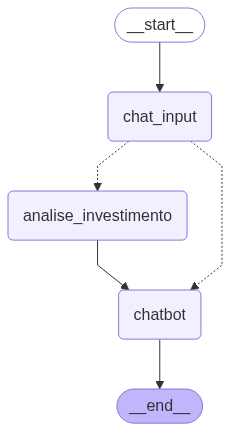

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [19]:
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]


#user_input = ["Quero análise técnica e fundamental da PETR4","Boa tarde, gostaria de algumas análises"]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
        
    start = time.time()
    initial_state = {
            "messages": [HumanMessage(content=mess)],
            "ticker": "",  # Definindo o ticker explicitamente
            "method_analysis": "" , # Definindo o método de análise|
            "dados_input" : ""
            
        }
 
    events = await graph.ainvoke(
            initial_state,
            config=config,
            stream_mode="values",
        )
    print(mess)
    end = time.time()
    print(f'O tempo de execucao foi de {end - start}')
    
    

Bom dia, como está?
O tempo de execucao foi de 1.7288031578063965
Olá, poderia me ajudar?
O tempo de execucao foi de 1.7656586170196533
Boa tarde, gostaria de algumas análises
O tempo de execucao foi de 1.8458797931671143
Oi, preciso de ajuda com investimentos
O tempo de execucao foi de 1.8651349544525146


[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -83.66%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Realize uma análise técnica da PETROBRAS
O tempo de execucao foi de 47.801156997680664


...

[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -83.67%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Error fetching URL: Client error '403 Forbidden' for url 'https://conteudos.xpi.com.br/esg/petrobras-petr4-deve-aprovar-projeto-de-captura-e-armazenamento-de-carbono-ate-agosto-cafe-com-esg-30-06/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Qual o melhor momento para comprar PETR4?
O tempo de execucao foi de 46.56664037704468


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `meta-llama/llama-4-scout-17b-16e-instruct` in organization `org_01j8j3rx6gf6g9kw7apk2439sa` service tier `on_demand` on tokens per day (TPD): Limit 500000, Used 507373, Requested 922. Please try again in 23m53.4394s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [20]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================== Ai Message ==================================


<think>
Okay, the user greeted me with "Bom dia, como está?" which means "Good morning, how are you?" in Portuguese. I should respond politely in Portuguese. Since they haven't provided any specific analysis data yet, I need to prompt them to input the required information so I can assist with their investment analysis. I'll make sure to keep it friendly and professional, following the guidelines given. Let me check the instructions again to ensure I don't miss anything. The response should be in Portuguese, concise, and encourage them to provide the necessary details. Alright, time to put that together.
</think>

Bom dia! Estou aqui à disposição. Para realizar a análise do ativo, preciso que você forneça os dados estruturados conforme o formato especificado (Technical, Fundamental, Valuation e Sentimen

# Melhorando o agente

In [6]:
import sys
sys.path.append("..")
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from agente_investimento import (
                      ChatValuationAsync,
                      ChatFundamentalistasAsync,
                      ChatSentimentoAsync,
                      ChatAnaliseTecnicaAsync,
                      ChatFundamentalistasComparacaoAsync)
from agente_investimento import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas, TratatandoDadosFundamentalistasComparacao
from agente_investimento import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from selenium import webdriver
import warnings
import pandas as pd
import asyncio
from langchain.schema import HumanMessage
from langgraph.types import Command
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    api_key=api_key,
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    #model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()

class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: list[str]
    dados_input : str
    next: str
    
    
class ModeloAnaliseTecnicaAsync():
    def __init__(
        self,
        query: str,
        ticker: str,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    async def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = await ChatAnaliseTecnicaAsync(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response

class ModeloValuationAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    async def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = await ChatValuationAsync(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]

        return response
    

class ModeloSentimentoAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        self.ticker = ticker
        self.query = query
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    async def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = await ChatSentimentoAsync(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response


class ModeloFundamentosAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        dados_inicio: str = "2022-06-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        self.query = query
        self.ticker = ticker
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    async def dados_fundamentalistas(self) -> List[Any]:
        return await tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    async def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = await self.dados_fundamentalistas()
        response = await ChatFundamentalistasAsync(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
                response = response.split('</think>')[1]
        return response

In [7]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command

async def process_technical(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise técnica para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise técnica assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise técnica
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos techincal')
   
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloAnaliseTecnicaAsync(ticker=ticker, query=query)
    response = await modelo.chat_analise_tecnica()
    
    dados_input = state['dados_input']
    
    response = dados_input.join(response)
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="tecnica")
            ]
        },
        goto="supervisor",
    )
    
    

async def process_valuation(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise de valuation para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de valuation assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise de valuation
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos valuation')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloValuationAsync(ticker=ticker, query=query)
    response = await modelo.chat_valuation()
    dados_input = state['dados_input']
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    
        
    
    
async def process_sentimetal(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise de sentimento para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise de sentimento assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise de sentimento
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos sentimental')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloSentimentoAsync(ticker=ticker, query=query)
    response= await modelo.chat_sentimento()
    dados_input = state['dados_input']
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
        
    
async def process_fundamental(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise fundamentalista para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloFundamentosAsync(ticker=ticker, query=query)
    response = await modelo.chat_fundamentalistas()
    dados_input = state['dados_input']
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    

async def analise_investimento(state: State) -> Command[Literal["supervisor"]]:
    print('entrei no analis investimento')
    ticker = state['ticker']

    tecnica = ModeloAnaliseTecnicaAsync(
            query=f"Qual a analise tecnica da {ticker}",
            ticker=ticker,
        )
    fundamentos = ModeloFundamentosAsync(
            query=f"Qual o fundamentos da {ticker}",
            ticker=ticker,
        
        )
    valuation = ModeloValuationAsync(
            query=f"Qual o valuation da {ticker}",
            ticker=ticker,
        )
    sentimento = ModeloSentimentoAsync(
            query=f"Qual o sentimento da {ticker}",
            ticker=ticker,
        )
     
    response = await asyncio.gather(
            tecnica.chat_analise_tecnica(),
            fundamentos.chat_fundamentalistas(),
            valuation.chat_valuation(),
            sentimento.chat_sentimento()
        )
        
    dados_input = state['dados_input']
    
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )

In [8]:
async def chat_input(state: State) -> State:
    """
    Processa a última mensagem do usuário para identificar um ticker de ação e o método de análise solicitado.

    Esta função lê uma lista de empresas e seus tickers de uma fonte externa.
    Constrói um prompt para um modelo de linguagem grande (LLM) instruindo-o a extrair
    o ticker da ação e o tipo de análise (fundamentals/valuation/sentimental/technical/Analise_investimento/chatbot)
    da última mensagem do usuário no estado fornecido.

    A função envia o prompt e a mensagem do usuário para o LLM, analisa a resposta
    para extrair o ticker e o método. Realiza uma verificação básica para garantir
    que o ticker extraído seja válido ou encontra um semelhante se necessário.
    Finalmente, atualiza o dicionário de estado com o ticker identificado e o método
    de análise e retorna o estado atualizado.

    Args:
        state (State): Um dicionário representando o estado atual da conversa,
                       espera-se que contenha uma chave "messages" com uma lista
                       de mensagens, onde a última é a do usuário.

    Returns:
        State: O dicionário de estado atualizado com as chaves 'ticker' e
               'method_analysis' preenchidas com os valores extraídos da
               resposta do LLM. O ticker pode ser uma string vazia se nenhum
               for identificado. O método de análise será um dos seguintes:
               fundamentals/valuation/sentimental/technical/Analise_investimento/chatbot.
    """
    
    print('Entrei na chat imput')
    
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    prompt = """
    Você é um assistente especializado em investimentos do mercado brasileiro. Extraia precisamente as seguintes informações:
    
    1. O ticker (código) da ação mencionada na mensagem do usuário. Se houver múltiplos tickers, identifique qual está sendo solicitado para análise.
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical). 
    3. Se for dado exemplos parecido com "Analise essa petrobras" ou "Vale apena investir na vale" responda (Analise_investimento).
    4. Se o usuário apenas mencionar uma empresa sem pedir análise específica, ainda extraia o ticker e defina o método como .
    5. Se não houver menção a nenhuma empresa ou ticker, retorne o método como "chatbot".
    
    Regras para identificação de tickers:
    - Tickers brasileiros geralmente terminam com números (ex: PETR4, VALE3)
    - Se o usuário mencionar apenas o nome da empresa (ex: "Petrobras"), identifique o ticker correto ({empresas_tickers})
    - Se houver ambiguidade, prefira o ticker mais líquido (geralmente terminados em 3 ou 4)
    - Se o usuário mencionar apenas o setor (ex: "bancos"), não retorne ticker específico
    
    Formato de resposta (apenas):
    <FORMATO RESPOSTAS>
    TICKER: [ticker em letras maiúsculas ou vazio se não identificado]
    MÉTODO: [fundamentals/valuation/sentimental/technical/Analise_investimento/chatbot]
    <FORMATO RESPOSTAS>
    """
    
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    # Fazer a chamada ao LLM
    response = await llm.ainvoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    ticker = ''
    metodo_analise = 'chatbot'
    
    # Extração mais robusta
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()
    
    if ticker:
        if ticker not in empresas_df['tic'].values:
            similar_tickers = empresas_df[empresas_df['tic'].str.contains(ticker[:2])]['tic'].tolist()
            if similar_tickers:
                ticker = similar_tickers[0]
                
    print(f"Ticker extraído: {ticker}")
    print(f"Método de análise: {metodo_analise}")
    
    state['ticker'] = ticker
    state['method_analysis'] = [metodo_analise]
    
    return state

In [9]:
async def chatbot(state: State) -> dict:
    """
    Gera uma resposta consolidada de análise de investimentos usando um LLM.

    Esta função constrói um prompt detalhado para um LLM (ChatGroq),
    fornecendo-lhe os resultados das análises anteriores (técnica, fundamentalista,
    sentimento, valuation) armazenados em `state['dados_input']` e a última
    mensagem do usuário de `state['messages']`.

    O LLM é instruído a agir como um assistente de investimentos, resumir
    cada tipo de análise, fornecer um comentário geral sobre o ativo,
    indicar um nível de confiança e considerações finais (incluindo riscos),
    formatando a saída em Markdown.

    Args:
        state (State): O dicionário de estado atual, que deve conter:
            - 'dados_input': Uma lista de strings, cada uma representando
                             o resultado de uma análise prévia, separadas
                             por marcadores específicos (ex: '###Technical Analysis###').
            - 'messages': Uma lista de mensagens da conversa, onde a última
                          é a consulta mais recente do usuário.
            - 'ticker': (Opcional) O ticker da ação sendo analisada.
            - 'method_analysis': (Opcional) O método de análise identificado.

    Returns:
        Dict[str, Any]: Um dicionário contendo a nova mensagem da IA ('messages'),
                        e preservando 'ticker', 'method_analysis', e 'dados_input'
                        do estado original. Em caso de erro durante o processamento,
                        a mensagem da IA conterá uma descrição do erro.
    """
    try:
        print('Entrei no chat bot')
        # Criar o prompt do sistema
        system_message = SystemMessage(content=f"""
       Você é um assistente especializado em análise de investimentos no mercado brasileiro.
        
        Voce recebe os seguintes dados 
        <DADOS INPUT>
        {state['dados_input']}.
        <DADOS INPUT>
        Nesses dados voce recebe informacao de analise técnica, analise fundamentalista, analise de sentimento e analise de valuation de acoes expecificado pelos usuarios.
        As analises nesses dados estao divididos pelo seguinte caracteres:
        - #########Technical Analysis#######  = Dentro dessa analise tem analise tecnica da acao.
        - ##########Fundamental Analysis######## = Dentro dessa analise tem a analise dos balancos da acao.
        - ############Valuation Analysis############ = Dentro dessa te a estimativa do valuation da acao.
        - #########Sentiment Analysis##### =  Dentro dessa temos a analise de noticias sobre a acao.
        
        Diretrizes:
        - Seja conciso e direto nas respostas
        - Use linguagem acessível, mas profissional
        - Quando não tiver certeza, admita as limitações
        - Sempre mencione os riscos envolvidos em investimentos
        - Evite recomendações diretas de compra/venda
        
        Voce deve dar o nivel de confianca da analise.
        Indique se analisando as entradas do agentes, a recomendacao e de compra, venda ou manter a acao.
    
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        llm = ChatGroq(
        api_key=api_key,
        #model="meta-llama/llama-4-scout-17b-16e-instruct",
        model="qwen-qwq-32b",
        temperature=0,
        stop_sequences=None,
    )
        
        # Fazer a chamada ao LLM
        response = await llm.ainvoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get('dados_input', "")
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input" : ""
 
        }

In [12]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command

# Defina os métodos de análise disponíveis
members = ["fundamentals", "technical", "sentimental", "valuation", "analise_investimento"]
options = members + ["FINISH"]

system_prompt = (
    "Você é um supervisor de análise de investimentos. Sua tarefa é gerenciar "
    f"os seguintes métodos de análise: {members}. Dada a solicitação do usuário, "
    "decida qual próximo método de análise deve ser executado. Cada método "
    "realizará sua análise específica e reportará resultados. Quando todas "
    "as análises necessárias estiverem concluídas, responda com FINISH."
)

class Router(TypedDict):
    """Determina o próximo método de análise. Se nenhum método for necessário, encerra."""
    next: Literal["fundamentals", "technical", "sentimental", "valuation", "analise_investimento", "FINISH"]


llm = ChatGroq(
               api_key=api_key,
    model="qwen-qwq-32b",
    temperature=0,
    stop_sequences=None,
)
        

def supervisor_node(state: State) -> Command[Literal["fundamentals", "technical", "sentimental", "valuation", "analise_investimento", "chatbot"]]:
    print('Entrei no supervisor')
    
    # Se não houver mais métodos de análise, vá para o chatbot
    if not state['method_analysis']:
        print("Todos os métodos de análise concluídos")
        return Command(
            goto="chatbot"
        )

    messages = [{"role": "system", "content": system_prompt},] + state['method_analysis']

    # Adiciona contexto sobre os métodos disponíveis
    context_message = (
        f"Métodos de análise disponíveis: {', '.join(state['method_analysis'])}. "
        "Escolha o próximo método a ser executado."
    )
    messages.append({"role": "system", "content": context_message})


    try:
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
    except Exception as e:
        print(f"Erro na seleção do método: {e}")
        # Caso de erro, use o primeiro método disponível
        goto = state['method_analysis'][0]
    
    # Se o método selecionado não está na lista de métodos restantes, 
    # escolha o primeiro disponível
    if goto not in state['method_analysis']:
        goto = state['method_analysis'][0]

    # Remover o método selecionado da lista de métodos
    remaining_methods = [m for m in state['method_analysis'] if m != goto]
    
    return Command(
        goto=goto,
        update={
    
            "method_analysis": remaining_methods,
            "next": goto
        }
    )


In [13]:
def verificacao_tickets(state: State) -> Command[Literal["chatinput","supervisor"]]:
    print('Entrei na verificaçao de tickets')
    ticker = state['ticker']
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    #ticks_ok = [tick for tick in ticker if tick in empresas_df['tic'].values]
    if ticker in empresas_df['tic'].values:
        return Command(
            goto="supervisor",
        )
    return Command(
        goto="chat_input",
         )

In [14]:
memory = MemorySaver()
graph_builder = StateGraph(State)
graph_builder.add_node("chatinput", chat_input)
graph_builder.add_node("verificacao_tickets", verificacao_tickets)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("analise_investimento", analise_investimento)
graph_builder.add_node("fundamentals", process_fundamental)
graph_builder.add_node("sentimental", process_sentimetal)
graph_builder.add_node("valuation", process_valuation)
graph_builder.add_node("technical", process_technical)
graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_edge("chatinput", "verificacao_tickets")
graph_builder.set_entry_point('chatinput')
#graph_builder.add_edge('chatinput', 'supervisor')
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(memory)

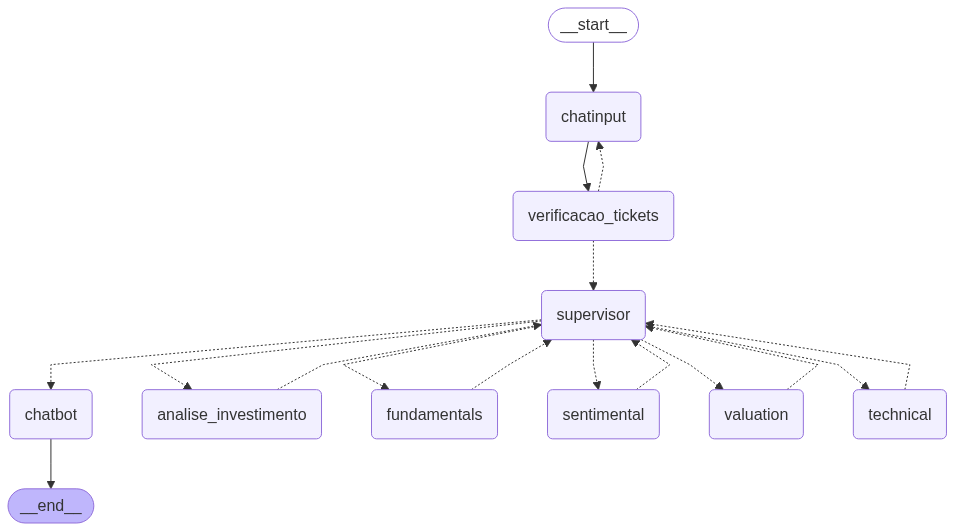

In [15]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [29]:
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    print('Pergunta feita:',mess)
    try:
        start = time.time()
        initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }
    
        events = await graph.ainvoke(
                initial_state,
                config=config,
                stream_mode="values",
            )
        print('Pergunta feita:',mess)
        end = time.time()
        print(f'O tempo de execucao foi de {end - start}')
    except:
        print('Erro na execucao')
        pass
    
    

Pergunta feita: Bom dia, como está?
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Bom dia, como está?
O tempo de execucao foi de 1.1508738994598389
Pergunta feita: Olá, poderia me ajudar?
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Olá, poderia me ajudar?
O tempo de execucao foi de 0.9398729801177979
Pergunta feita: Boa tarde, gostaria de algumas análises
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Boa tarde, gostaria de algumas análises
O tempo de execucao foi de 1.2284419536590576
Pergunta feita: Oi, preciso de ajuda com investimentos
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Oi, preciso de ajuda com investimentos
O tempo de execucao foi de 14.15812635421753
Pergunta feita: Realize uma análise técnica da 

[*********************100%***********************]  1 of 1 completed


Nao tem returnOnEquity
Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Erro na execucao
Pergunta feita: Faça uma análise de valuation do Banco do AMAZONIA
Entrei na chat imput
Ticker extraído: 
Método de análise: valuation
Entrei na verificaçao de tickets
Pergunta feita: Faça uma análise de valuation do Banco do AMAZONIA
O tempo de execucao foi de 2.0515034198760986
Pergunta feita: Preciso do valuation da BANDO MERCANTIL
Entrei na chat imput
Ticker extraído: 
Método de análise: valuation
Entrei na verificaçao de tickets
Pergunta feita: Preciso do valuation da BANDO MERCANTIL
O tempo de execucao foi de 15.334713697433472
Pergunta feita: Me ajude com o valuation da ECORODOVIAS
Entrei na chat imput
Ticker extraído: ECOR3
Método de análise: valuation
Entrei na verificaçao de tickets
Entrei no supervisor
Entrei nos valuation


...

Erro na execucao
Pergunta feita: Quero análise técnica e fundamental da PETR4
Entrei na chat imput
Ticker extraído: PETR4
Método de análise: fundamentals/technical
Entrei na verificaçao de tickets
Entrei no supervisor
Pergunta feita: Quero análise técnica e fundamental da PETR4
O tempo de execucao foi de 3.7346911430358887
Pergunta feita: Mostre o sentimento e valuation da VALE3
Entrei na chat imput
Ticker extraído: 
Método de análise: chatbot
Entrei na verificaçao de tickets
Pergunta feita: Mostre o sentimento e valuation da VALE3
O tempo de execucao foi de 27.3614604473114
Pergunta feita: Preciso de uma análise completa da BBDC3
Entrei na chat imput
Ticker extraído: BBDC3
Método de análise: Analise_investimento
Entrei na verificaçao de tickets
Entrei no supervisor
Pergunta feita: Preciso de uma análise completa da BBDC3
O tempo de execucao foi de 13.78983759880066
Pergunta feita: Como está BRASKEM em termos técnicos e sentimentais?
Entrei na chat imput
Ticker extraído: BRKM3
Método d

[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Erro na execucao
Pergunta feita: Vale a pena entrar em MAGAZIN LUIZA agora?
Entrei na chat imput
Ticker extraído: MGLU3
Método de análise: Analise_investimento
Entrei na verificaçao de tickets
Entrei no supervisor
Pergunta feita: Vale a pena entrar em MAGAZIN LUIZA agora?
O tempo de execucao foi de 2.226076602935791


In [ ]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================ Human Message =================================

Olá, poderia me ajudar?

================================ Human Message =================================

Boa tarde, gostaria de algumas análises

================================ Human Message =================================

Oi, preciso de ajuda com investimentos

================================ Human Message =================================

Realize uma análise técnica da PETROBRAS

================================ Human Message =================================

Quero ver a análise técnica da VALE

================================ Human Message =================================

Me mostre os indicadores técnicos da ITUB4

================================ Human Message =================================

Poderia fazer uma análise técnica da Banco do BRASIL?

================================ Human 

: 

# Agente com Memory persistente com Postgres

In [16]:
import sys
sys.path.append("..")
from agente_investimento import langgraph_main
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
import time

In [17]:
graph_builder = langgraph_main()
memory = MemorySaver()
graph = graph_builder.compile(memory)

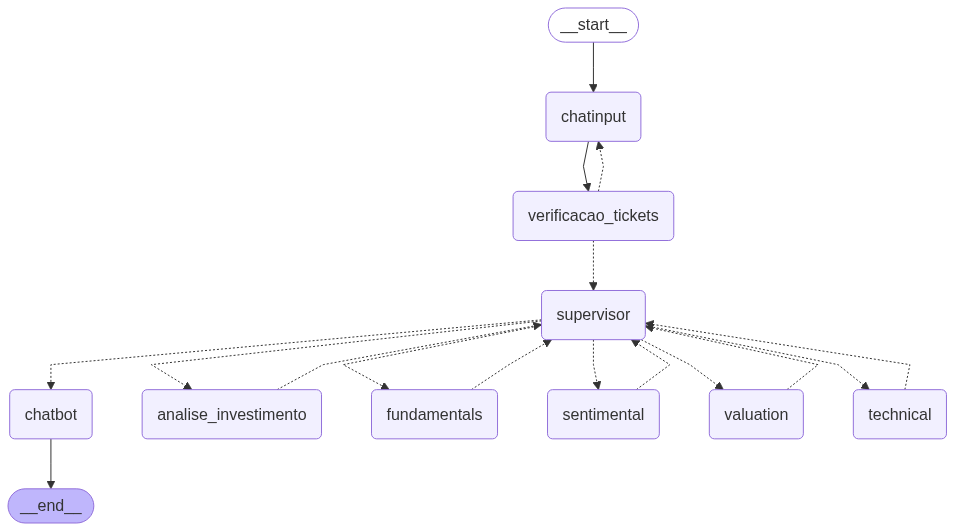

In [18]:
#https://github.com/langchain-ai/langchain/issues/30427
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
from psycopg_pool import ConnectionPool
from psycopg_pool import AsyncConnectionPool
import os
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

"""user_input = [
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",]"""

    # Configuração do stream


connection_kwargs = {
    "autocommit": True,
    "prepare_threshold": 0,
}

db_uri = os.environ.get("DB_URI")

for mess in user_input:
        # Configuração inicial do estado
    print('Pergunta feita:',mess)
    
    start = time.time()
    initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }
    async with AsyncConnectionPool(conninfo=db_uri, max_size=20,kwargs=connection_kwargs,) as pool:
            
        checkpointer = AsyncPostgresSaver(pool)

        await checkpointer.setup()
            
        graph_builder = langgraph_main()

        graph = graph_builder.compile(checkpointer=checkpointer)
            
        config = {"configurable": {"thread_id": "1"}}
        
        events = await graph.ainvoke(
                    initial_state,
                    config=config,
                    stream_mode="values",
                    
                )
        checkpoint = await checkpointer.aget(config)
    end = time.time()
    print(f'O tempo de execucao foi de {end - start}')
    
    

In [22]:
checkpoint

{'v': 3,
 'id': '1f057455-0263-602a-8548-4252dd66f423',
 'ts': '2025-07-02T13:06:05.752529+00:00',
 'pending_sends': [],
 'versions_seen': {'chatbot': {'branch:to:chatbot': '00000000000000000000000000001353.0.08257971648679996'},
  '__input__': {},
  '__start__': {'__start__': '00000000000000000000000000001345.0.9404692668347373'},
  'chatinput': {'branch:to:chatinput': '00000000000000000000000000001346.0.5468204393501226'},
  'technical': {'branch:to:technical': '00000000000000000000000000001351.0.25745074303021276'},
  'valuation': {'branch:to:valuation': '00000000000000000000000000001337.0.2409735992936658'},
  'supervisor': {'branch:to:supervisor': '00000000000000000000000000001352.0.028417041983908486'},
  'sentimental': {'branch:to:sentimental': '00000000000000000000000000001349.0.8011785748527356'},
  'fundamentals': {'branch:to:fundamentals': '00000000000000000000000000001335.0.4599374248611242'},
  'verificacao_tickets': {'branch:to:verificacao_tickets': '000000000000000000000

# Chamando a API

- Primeiro ative o servidor: 

Para rodar o docker no terminal, execute o seguinte comando:

```	bash
docker build -t agente-investimento-app .
docker run -p 3000:3000 agente-investimento-app

# ou se quiser rodar com o docker-compose use o seguinte comando:

docker-compose build
docker-compose up
```


- 

In [23]:
import sys
sys.path.append("../")
from agente_investimento.consulta_banco_postgree import PostgresDBConsult
consulta = PostgresDBConsult()

print(consulta.inspecionar_tabelas())

#consulta.drop_table(tabela="checkpoints")

#consulta.drop_table(tabela="checkpoint_blobs")

#consulta.drop_table(tabela="checkpoint_writes")

#consulta.drop_table(tabela="checkpoint_migrations")


['checkpoint_blobs', 'checkpoint_migrations', 'checkpoints', 'checkpoint_writes']


In [24]:
import requests
import time

user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

#user_input = ["Quero análise sentimento da PETR4"]



for mess in user_input:
    try:
        start = time.time()
        url = f"http://localhost:3000/chatbot/{mess}"
        response = requests.get(url)
        data = response.json()
        end = time.time()
        execution_time = end - start
        
        pergunta = data['messages'][0]['content']
        llm_response = data['messages'][1]['content']
        ticker = data.get('ticker', '')
        method_analysis = data.get('method_analysis', '')

        
        print('Pergunta feita:',mess)
        print(data['messages'][-1]['content'].split('\n\n'))
        print(f'O tempo de execucao foi de {end - start}')
        print('-'* 100)
    except Exception as e:
        print(f'Erro {e}')
        print('-'* 100)
    

Pergunta feita: Bom dia, como está?
['Bom dia! Estou bem, obrigado por perguntar. Estou aqui para ajudá-lo a analisar os dados de investimento fornecidos. Por favor, forneça os dados que você gostaria que eu analisasse. Estou preparado para examinar as análises técnica, fundamentalista, de sentimento e de valuation da ação especificada.', 'Lembre-se de que os investimentos envolvem riscos e não há garantias de retorno. Minha análise será baseada nos dados fornecidos e terá um caráter informativo e educacional.', 'Por favor, compartilhe os dados!']
O tempo de execucao foi de 5.648140907287598
----------------------------------------------------------------------------------------------------
Pergunta feita: Olá, poderia me ajudar?
['Olá! Estou aqui para ajudar. Por favor, forneça os dados de análise que você recebeu, utilizando os caracteres específicos para cada tipo de análise:', '- #########Technical Analysis#######\n- ##########Fundamental Analysis########\n- ############Valuation A

In [25]:
banco = requests.get('http://localhost:3000/return-db/1')

In [26]:
banco

<Response [200]>

In [27]:
banco.json()

{'v': 3,
 'id': '1f057471-09a3-6064-85e5-2882b00f6f81',
 'ts': '2025-07-02T13:18:38.132001+00:00',
 'pending_sends': [],
 'versions_seen': {'chatbot': {'branch:to:chatbot': '00000000000000000000000000001472.0.5493591165180554'},
  '__input__': {},
  '__start__': {'__start__': '00000000000000000000000000001510.0.7822138726637058'},
  'chatinput': {'branch:to:chatinput': '00000000000000000000000000001509.0.5195613400874793'},
  'technical': {'branch:to:technical': '00000000000000000000000000001422.0.05487360280247511'},
  'valuation': {'branch:to:valuation': '00000000000000000000000000001337.0.2409735992936658'},
  'supervisor': {'branch:to:supervisor': '00000000000000000000000000001471.0.9425724949254772'},
  'sentimental': {'branch:to:sentimental': '00000000000000000000000000001349.0.8011785748527356'},
  'fundamentals': {'branch:to:fundamentals': '00000000000000000000000000001470.0.42369644544842144'},
  'verificacao_tickets': {'branch:to:verificacao_tickets': '00000000000000000000000

# Adcionando comparacao de acoes

In [28]:
import sys
sys.path.append("..")
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from agente_investimento import (
                      ChatValuationAsync,
                      ChatFundamentalistasAsync,
                      ChatSentimentoAsync,
                      ChatAnaliseTecnicaAsync,
                      ChatFundamentalistasComparacaoAsync)
from agente_investimento import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas, TratatandoDadosFundamentalistasComparacao
from agente_investimento import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from selenium import webdriver
import warnings
import pandas as pd
import asyncio
from dotenv import load_dotenv
from agente_investimento import get_llm
from typing import Final
import json
from langchain.schema import HumanMessage
from langgraph.types import Command


DEFAULT_MODEL: Final = "meta-llama/llama-4-scout-17b-16e-instruct"

warnings.filterwarnings('ignore')

load_dotenv()


try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: list[str]
    dados_input : str
    next: str
    comparacao: bool
    
    
llm = ChatGroq(
    api_key=api_key,
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    #model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

In [29]:
async def chat_input(state: State) -> State:
    """
    Processes the user's last message to identify a stock ticker and the requested analysis method.

    This function reads a list of companies and their tickers from an external source.
    It builds a prompt for a large language model (LLM) instructing it to extract
    the stock ticker and the type of analysis (fundamentals, valuation, sentimental, technical, analise_investimento, chatbot)
    from the user's last message in the provided state.

    The function sends the prompt and the user's message to the LLM, parses the response
    to extract the ticker and method. It performs a basic check to ensure
    the extracted ticker is valid or finds a similar one if necessary.
    Finally, it updates the state dictionary with the identified ticker and analysis method,
    and returns the updated state.

    Args:
        state (State): A dictionary representing the current conversation state,
                       expected to contain a "messages" key with a list
                       of messages, where the last one is from the user.

    Returns:
        State: The updated state dictionary with the 'ticker' and
               'method_analysis' keys filled in with the values extracted from
               the LLM response. The ticker may be an empty string if none
               was identified. The analysis method will be one of the following:
               fundamentals, valuation, sentimental, technical, analise_investimento, chatbot.
    """

    empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )

    prompt = """
    Você é um assistente especializado em investimentos do mercado brasileiro. Extraia precisamente as seguintes informações:
    
    1. O ticker (código) da ação mencionada na mensagem do usuário. Se houver múltiplos tickers, identifique qual está sendo solicitado para análise.
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical). 
    3. Se for dado exemplos parecido com "Analise essa petrobras" ou "Vale apena investir na vale" responda (analise_investimento).
    4. Se o usuário apenas mencionar uma empresa sem pedir análise específica, ainda extraia o ticker e defina o método como .
    5. Se não houver menção a nenhuma empresa ou ticker, retorne o método como "chatbot".
    
    Regras para identificação de tickers:
    - Tickers brasileiros geralmente terminam com números (ex: PETR4, VALE3)
    - Se o usuário mencionar apenas o nome da empresa (ex: "Petrobras"), identifique o ticker correto ({empresas_tickers})
    - Se houver ambiguidade, prefira o ticker mais líquido (geralmente terminados em 3 ou 4)
    - Se o usuário mencionar apenas o setor (ex: "bancos"), não retorne ticker específico
    
    Formato de resposta (apenas):
    <FORMATO RESPOSTAS>
    TICKER: [ticker em letras maiúsculas ou vazio se não identificado]
    MÉTODO: [Deve retornar strings, Caso haja mais de um método, separe-as strings por vírgula, ex: ["technical", "valuation"]]
    <FORMATO RESPOSTAS>
    """

    empresas_tickers = "\n".join(
        [
            f"{empresa} ({ticker})"
            for empresa, ticker in zip(empresas_df["Empresa"], empresas_df["tic"])
        ]
    )
    prompt = prompt.format(empresas_tickers=empresas_tickers)

    last_message = state["messages"][-1]

    llm = get_llm( 
    )

    response = await llm.ainvoke(
        [HumanMessage(content=prompt), HumanMessage(content=last_message.content)]
    )

    response_text = response.content

    ticker = ""
    metodo_analise = "chatbot"

    # Extração mais robusta
    for line in response_text.split("\n"):  # type: ignore[union-attr]
        if line.startswith("TICKER:"):
            ticker = line.split(":")[1].strip()
        elif line.startswith("MÉTODO:"):
            metodo_analise = line.split(":")[1].strip()

    if isinstance(metodo_analise, str) and metodo_analise.startswith("["):
        metodo_analise = json.loads(metodo_analise)
    else:
        metodo_analise = [m.strip() for m in metodo_analise.split(",") if m.strip()]  # type: ignore
        
    if isinstance(ticker, str) and ticker.startswith("["):
        ticker = json.loads(ticker)
    else:
        ticker = [m.strip() for m in ticker.split(",") if m.strip()]  # type: ignore

    state["ticker"] = ticker
    state["method_analysis"] = metodo_analise  # type: ignore

    return state

In [30]:
from typing_extensions import Literal

def verificacao_tickets(state: State) -> Command[Literal["chatinput", "roteador_analise"]]:
    """
    Checks whether the extracted ticker is valid or if the analysis method corresponds to the chatbot.

    This function performs a check on the current state to determine whether the provided ticker
    is present in the list of valid companies (loaded from an external source) or if the analysis
    method includes 'chatbot'. Based on this, it decides whether the flow should proceed
    to the supervisor node or return to the user input node.

    Args:
        state (State): The current state dictionary, containing at least the keys
                       'ticker' (str) and 'method_analysis' (list).

    Returns:
        Command[Literal["chatinput", "supervisor"]]: A command indicating the next node
            to be executed in the flow:
            - "supervisor" if the ticker is valid or the analysis method is 'chatbot'.
            - "chat_input" otherwise, indicating that the user input should be revised.
    """
    ticker = state.get("ticker", "")
    metodo_analise = state.get("method_analysis", [])
    empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )
    if isinstance(ticker, list):
        ticker = [tick for tick in ticker if tick in empresas_df['tic'].values]
    if isinstance(ticker,str):
        ticker = ticker in empresas_df["tic"].values
    if ticker or any(
        metodo == "chatbot" for metodo in metodo_analise
    ):
        return Command(
            goto="roteador_analise",
        )
    return Command(
        goto="chat_input",
    )

In [31]:
def roteador_analise(state: State) -> Command[Literal["supervisor", "supervisor_comparacao"]]:
    """
    Roteia o fluxo de análise com base na quantidade de tickers presentes no estado.
    
    Se houver mais de um ticker, direciona para o supervisor de comparação.
    Caso contrário, direciona para o supervisor de análise individual.
    
    Args:
        state (State): Estado atual contendo os tickers a serem analisados
        
    Returns:
        Command: Comando indicando o próximo nó do fluxo (supervisor ou supervisor_comparacao)
    """
    ticker = state.get("ticker", "")
    if len(ticker) > 1:
        metodo_analise = state.get("method_analysis")
        metodo_analise = [metodo+"_comparacao" for metodo in metodo_analise]
        print("Entrou em supervisor_comparacao")
        return Command(
            goto="supervisor_comparacao",
            update={"method_analysis": metodo_analise}
        )
    print("Entrou em supervisor")
    return Command(
        goto="supervisor",
    )

In [32]:
from typing import Literal

from langgraph.types import Command
from typing_extensions import TypedDict

from agente_investimento import get_llm
from agente_investimento import State

from typing import Final

from dotenv import load_dotenv
import os

load_dotenv()

DEFAULT_MODEL: Final = "qwen-qwq-32b"

MODEL_ID_SUPERVISOR: str = os.getenv("MODEL_ID_SUPERVISOR", DEFAULT_MODEL)

members_comparacao = [
    "fundamentals_comparacao",
    "technical_comparacao",
    "sentimental_comparacao",
    "valuation_comparacao",
    "analise_investimento_comparacao",
]
options = members_comparacao + ["FINISH"]

system_prompt = (
    "Você é um supervisor de análise de investimentos. Sua tarefa é gerenciar "
    f"os seguintes métodos de análise: {members_comparacao}. Dada a solicitação do usuário, "
    "decida qual próximo método de análise deve ser executado. Cada método "
    "realizará sua análise específica e reportará resultados. Quando todas "
    "as análises necessárias estiverem concluídas, responda com FINISH."
)


class Router_comparacao(TypedDict):
    """Determina o próximo método de análise. Se nenhum método for necessário, encerra."""

    next: Literal[
        "fundamentals_comparacao",
        "technical_compacao",
        "sentimental_comparacao",
        "valuation_comparacao",
        "analise_investimento_comparacao",
        "FINISH",
    ]


def supervisor_node_comparacao(
    state: State,
) -> Command[
    Literal[
        "fundamentals_comparacao",
        "technical_comparacao",
        "sentimental_comparacao",
        "valuation_comparacao",
        "analise_investimento_comparacao",
        "chat_bot_comparacao",
    ]
]:
    """
    Executes the supervisor node, which decides which analysis method should be executed next.
    The supervisor node checks if there are still analysis methods available and, if so,
    uses a language model to determine which method should be executed next.
    If no analysis methods remain, the workflow is redirected to the chatbot node.

    Args:
        state (State): The current state dictionary, which must contain:
                       'method_analysis': A list of available analysis methods.

    Returns:
        Command: A command indicating the next node to be executed and updating the state.
                 If all analysis methods have been completed, it redirects to the chatbot node.
    """
    metodo_analise = state["method_analysis"]

    if not metodo_analise:
        print("Todos os métodos de análise concluídos")
        return Command(goto="chat_bot_comparacao")

    messages = [
        {"role": "system", "content": system_prompt},
    ] + metodo_analise

    context_message = (
        f"Métodos de análise disponíveis: {', '.join(state['method_analysis'])}. "
        "Escolha o próximo método a ser executado."
    )
    messages.append({"role": "system", "content": context_message})

    llm = get_llm(
        model=MODEL_ID_SUPERVISOR,
        temperature=0,
        stop_sequences=None,
    )

    try:
        response = llm.with_structured_output(Router).invoke(messages)  # type: ignore
        goto = response["next"]  # type: ignore
    except Exception as e:  # pylint: disable=W0718
        print(f"Erro na seleção do método: {e}")
        # Caso de erro, use o primeiro método disponível
        goto = state["method_analysis"][0]

    if goto not in state["method_analysis"]:
        goto = state["method_analysis"][0]

    remaining_methods = [m for m in state["method_analysis"] if m != goto]

    return Command(
        goto=goto, update={"method_analysis": remaining_methods, "next": goto}
    )

In [33]:
from typing import Literal

from langgraph.types import Command
from typing_extensions import TypedDict

from agente_investimento import get_llm
from agente_investimento import State

from typing import Final

from dotenv import load_dotenv
import os

load_dotenv()

DEFAULT_MODEL: Final = "qwen-qwq-32b"

MODEL_ID_SUPERVISOR: str = os.getenv("MODEL_ID_SUPERVISOR", DEFAULT_MODEL)

members = [
    "fundamentals",
    "technical",
    "sentimental",
    "valuation",
    "analise_investimento",
]
options = members + ["FINISH"]

system_prompt = (
    "Você é um supervisor de análise de investimentos. Sua tarefa é gerenciar "
    f"os seguintes métodos de análise: {members}. Dada a solicitação do usuário, "
    "decida qual próximo método de análise deve ser executado. Cada método "
    "realizará sua análise específica e reportará resultados. Quando todas "
    "as análises necessárias estiverem concluídas, responda com FINISH."
)


class Router(TypedDict):
    """Determina o próximo método de análise. Se nenhum método for necessário, encerra."""

    next: Literal[
        "fundamentals",
        "technical",
        "sentimental",
        "valuation",
        "analise_investimento",
        "FINISH",
    ]


def supervisor_node(
    state: State,
) -> Command[
    Literal[
        "fundamentals",
        "technical",
        "sentimental",
        "valuation",
        "analise_investimento",
        "chat_bot",
    ]
]:
    """
    Executes the supervisor node, which decides which analysis method should be executed next.
    The supervisor node checks if there are still analysis methods available and, if so,
    uses a language model to determine which method should be executed next.
    If no analysis methods remain, the workflow is redirected to the chatbot node.

    Args:
        state (State): The current state dictionary, which must contain:
                       'method_analysis': A list of available analysis methods.

    Returns:
        Command: A command indicating the next node to be executed and updating the state.
                 If all analysis methods have been completed, it redirects to the chatbot node.
    """
    metodo_analise = state["method_analysis"]

    if not metodo_analise:
        print("Todos os métodos de análise concluídos")
        return Command(goto="chat_bot")

    messages = [
        {"role": "system", "content": system_prompt},
    ] + metodo_analise

    context_message = (
        f"Métodos de análise disponíveis: {', '.join(state['method_analysis'])}. "
        "Escolha o próximo método a ser executado."
    )
    messages.append({"role": "system", "content": context_message})

    llm = get_llm(
        model=MODEL_ID_SUPERVISOR,
        temperature=0,
        stop_sequences=None,
    )

    try:
        response = llm.with_structured_output(Router).invoke(messages)  # type: ignore
        goto = response["next"]  # type: ignore
    except Exception as e:  # pylint: disable=W0718
        print(f"Erro na seleção do método: {e}")
        # Caso de erro, use o primeiro método disponível
        goto = state["method_analysis"][0]

    if goto not in state["method_analysis"]:
        goto = state["method_analysis"][0]

    remaining_methods = [m for m in state["method_analysis"] if m != goto]

    return Command(
        goto=goto, update={"method_analysis": remaining_methods, "next": goto}
    )

In [40]:
from typing import Any, Dict

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

from agente_investimento import get_llm
from agente_investimento import State

from typing import Final

from dotenv import load_dotenv
import os

load_dotenv()

#DEFAULT_MODEL: Final = "meta-llama/llama-4-scout-17b-16e-instruct"

DEFAULT_MODEL: Final = "meta-llama/llama-4-maverick-17b-128e-instruct"

MODEL_ID_CHAT_RESPONSE: str = os.getenv("MODEL_ID_CHAT_RESPONSE", DEFAULT_MODEL)


async def chat_bot_comparacao(state: State) -> Dict[str, Any]:
    """
    Generates a consolidated investment analysis response using an LLM.

    This function builds a detailed prompt for an LLM (ChatGroq),
    providing it with the results of previous analyses (technical, fundamental,
    sentiment, valuation) stored in `state['dados_input']` and the user's latest
    message from `state['messages']`.

    The LLM is instructed to act as an investment assistant, summarize
    each type of analysis, provide an overall commentary on the asset,
    indicate a confidence level, and give final considerations (including risks),
    formatting the output in Markdown.

    Args:
        state (State): The current state dictionary, which must include:
            - 'dados_input': A list of strings, each representing the result
                             of a previous analysis, separated by specific markers
                             (e.g., '###Technical Analysis###').
            - 'messages': A list of conversation messages, where the last
                          one is the most recent user query.
            - 'ticker': (Optional) The stock ticker being analyzed.
            - 'method_analysis': (Optional) The identified analysis method.

    Returns:
        Dict[str, Any]: A dictionary containing the new AI message ('messages'),
                        and preserving 'ticker', 'method_analysis', and 'dados_input'
                        from the original state. In case of processing errors,
                        the AI message will include an error description.
    """

    try:
        system_message = SystemMessage(
            content=f"""
       Você é um assistente especializado em análise de investimentos no mercado brasileiro, com foco em análise comparativa entre diferentes ações.
        
        Voce recebe os seguintes dados 
        <DADOS INPUT>
        {state["dados_input"]}.
        </DADOS INPUT>

        Nesses dados você pode receber informações comparativas de múltiplas ações, incluindo análise técnica, fundamentalista, sentimento e valuation. As análises estão divididas pelos seguintes marcadores:

        - #########Technical Analysis#######
        Análise técnica comparativa das ações, incluindo indicadores de preço, volume e momentum

        - ##########Fundamental Analysis########
        Comparação dos balanços e indicadores fundamentalistas entre as empresas

        - ############Valuation Analysis############
        Análise comparativa das avaliações e preços-alvo das ações

        - #########Sentiment Analysis#####
        Análise comparativa do sentimento de mercado e notícias sobre as empresas

        Diretrizes para Análise Comparativa:
        - Identifique os pontos fortes e fracos de cada ação
        - Compare objetivamente os indicadores entre as empresas
        - Destaque as vantagens competitivas de cada empresa
        - Analise os riscos específicos de cada ação
        - Use linguagem acessível e profissional
        - Quando houver incertezas, deixe isso claro
        - Evite recomendações diretas de compra/venda

        Sua Análise Deve Incluir:
        1. Tabela comparativa dos principais indicadores
        2. Ranking das ações em cada aspecto analisado
        3. Nível de confiança da análise comparativa
        4. Perspectivas para cada ação
        5. Riscos específicos de cada empresa
        6. Pontos de atenção para o investidor

        Formato da Resposta:
        1. Resumo Comparativo
        2. Análise Detalhada por Categoria
        3. Ranking Geral
        4. Considerações Finais

        Observação: Mantenha o foco na comparação objetiva entre as ações, destacando os diferenciais de cada uma.
        
        """
        )

        last_message = state["messages"][-1]

        messages = [system_message, HumanMessage(content=f"{last_message.content}")]

        llm = get_llm(model=MODEL_ID_CHAT_RESPONSE)

        response = await llm.ainvoke(messages)

        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get("dados_input", ""),
        }

    except Exception as e:  # pylint: disable=W0718
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": "",
        }
        

In [41]:
from agente_investimento import ModeloFundamentosComparacaoAsync
from agente_investimento import ModeloAnaliseTecnicaComparacao
from agente_investimento import ModeloValuationComparacao
from agente_investimento import ModeloSentimentoComparacao

async def process_fundamental_comparacao(state: State) -> Command[Literal["supervisor_comparacao"]]:
    """
    Executa a comparação de análise fundamentalista para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloFundamentosComparacaoAsync(tickers=tickers, query=query)
    response = await modelo.chat_fundamentalistas_comparacao()
    #dados_input = state['dados_input']
    #response = dados_input.join(response)
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="fundamental_comparacao")
            ]
        },
        goto="supervisor_comparacao",
        )
    

async def process_technical_comparacao(state: State) -> Command[Literal["supervisor_comparacao"]]:
    """
    Executa a comparação de análise tecnica para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos tecnica comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloAnaliseTecnicaComparacao(tickers=tickers, query=query, periodo="3Y", intervalo="1mo",)
    response = await modelo.chat_analise_tecnica_comparacao()
    #dados_input = state['dados_input']
    #response = dados_input.join(response)
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="technical_comparacao")
            ]
        },
        goto="supervisor_comparacao",
        )
    
    
async def process_valuation_comparacao(state: State) -> Command[Literal["supervisor_comparacao"]]:
    """
    Executa a comparação de análise valuation para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]

    modelo = ModeloValuationComparacao(query=query,tickers=tickers)

    response = await modelo.chat_valuation()
    
    #dados_input = state['dados_input']
    #response = dados_input.join(response)
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation_comparacao")
            ]
        },
        goto="supervisor_comparacao",
        )
    
    
async def process_sentimento_comparacao(state: State) -> Command[Literal["supervisor_comparacao"]]:
    """
    Executa a comparação de análise de sentimento para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos sentimentos comparacao')

    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloSentimentoComparacao(tickers=tickers, query=query)
    response = await modelo.chat_sentimento()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    else:
        response = ''
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="sentimento_comparacao")
            ]
        },
        goto="supervisor_comparacao",
        )
    
    
async def analise_investimento_comparacao(state: State) -> Command[Literal["supervisor_comparacao"]]:
    
    """
    Executes fundamental analysis, valuation analysis, technical analysis and sentiment analysis for the specified ticker in the state.

    Retrieves the ticker and the user's last message from the state.
    Instantiates and calls the asynchronous fundamental analysis model.
    Adds the model's response to the 'dados_input' list in the state.

    Args:
        state (State): The current state dictionary, containing 'ticker',
                       'messages', and 'dados_input'.

    Returns:
        Optional[State]: The updated state with the fundamental analysis response
                         added to 'dados_input', or None if an error occurs.
    """
    
    print('Entrei em analise investimento comparacao')
    tickers = state['ticker']
    
    query = state["messages"][-1]
    

    tecnica = ModeloAnaliseTecnicaComparacao(
        query=query,
        tickers=tickers,
    )
    fundamentos = ModeloFundamentosComparacaoAsync(
        query=query,
        tickers=tickers,
    )
    valuation = ModeloValuationComparacao(
        query=query,
        tickers=tickers,
    )
    sentimento = ModeloSentimentoComparacao(
        query=query,
        tickers=tickers,
    )

    response = await asyncio.gather(
        tecnica.chat_analise_tecnica_comparacao(),
        fundamentos.chat_fundamentalistas_comparacao(),
        valuation.chat_valuation(),
        sentimento.chat_sentimento(),
    )

    if isinstance(dados_input, list):  # type: ignore
        dados_input = "\n".join(dados_input) if dados_input else ""

    response = "\n".join(response)  # type: ignore

    response = f"{dados_input}\n{response}" if dados_input else response  # type: ignore
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="analise_investimento_comparacao")
            ]
        },
        goto="supervisor_comparacao",
        )
    


In [42]:
from langgraph.graph import END, StateGraph

from agente_investimento import (
    analise_investimento,
    process_fundamental,
    process_sentimetal,
    process_technical,
    process_valuation,
)
from agente_investimento import chatbot
#from agente_investimento import chat_input
from agente_investimento import State
#from agente_investimento import supervisor_node
#from agente_investimento import verificacao_tickets



def langgraph_main() -> StateGraph:
    graph_builder = StateGraph(State)
    graph_builder.add_node("chatinput", chat_input)
    graph_builder.add_node("verificacao_tickets", verificacao_tickets)
    graph_builder.add_node("chat_bot", chatbot)
    graph_builder.add_node("analise_investimento", analise_investimento)
    graph_builder.add_node("analise_investimento_comparacao", analise_investimento_comparacao)
    graph_builder.add_node("fundamentals", process_fundamental)
    graph_builder.add_node("fundamentals_comparacao", process_fundamental_comparacao)
    graph_builder.add_node("sentimental", process_sentimetal)
    graph_builder.add_node("sentimental_comparacao", process_sentimento_comparacao)
    graph_builder.add_node("valuation", process_valuation)
    graph_builder.add_node("valuation_comparacao", process_valuation_comparacao)
    graph_builder.add_node("technical", process_technical)
    graph_builder.add_node("technical_comparacao", process_technical_comparacao)
    graph_builder.add_node("supervisor", supervisor_node)
    graph_builder.add_node("supervisor_comparacao", supervisor_node_comparacao)
    graph_builder.add_node("roteador_analise", roteador_analise)
    graph_builder.add_node("chat_bot_comparacao", chat_bot_comparacao)
    graph_builder.add_edge("chatinput", "verificacao_tickets")
    graph_builder.set_entry_point("chatinput")
    graph_builder.add_edge("chat_bot", END)
    graph_builder.add_edge("chat_bot_comparacao", END)

    return graph_builder

In [43]:
checkpoint = MemorySaver()
graph_builder = langgraph_main()
graph = graph_builder.compile(checkpointer=checkpoint)

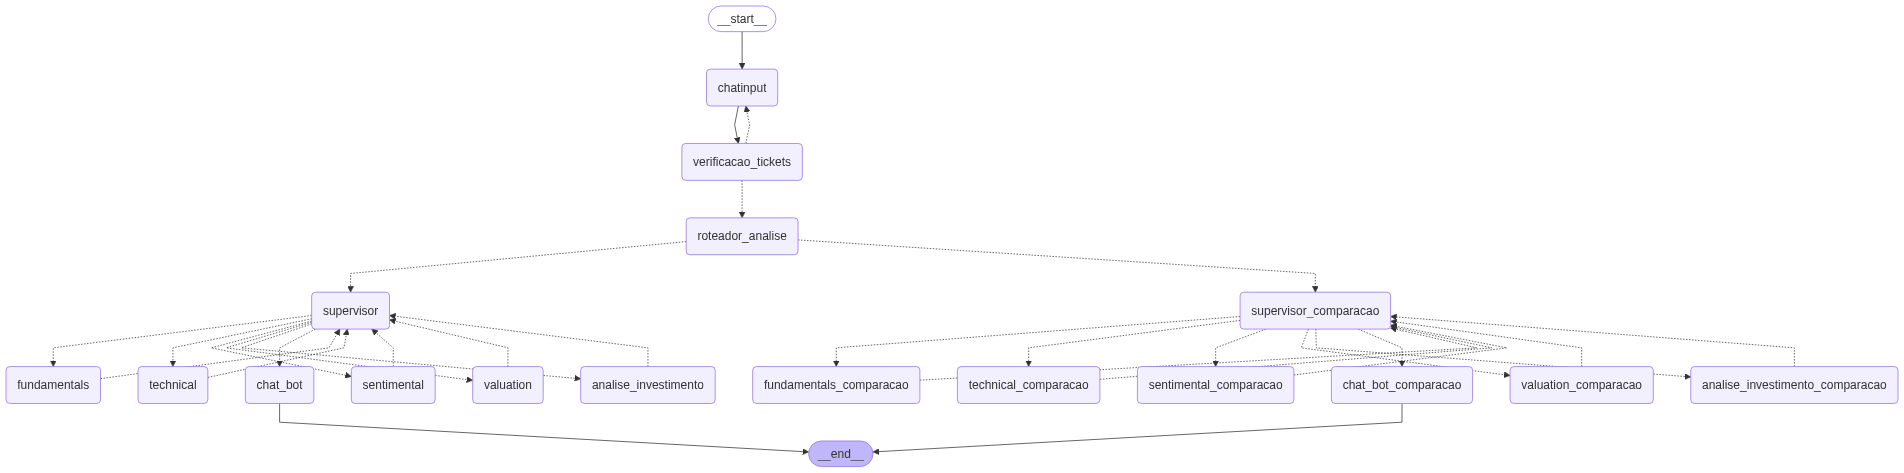

In [44]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Exception")
    pass

In [45]:
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
    
    
    # Análises Técnicas Comparativas
    "Compare os indicadores técnicos da PETROBRAS e VALE",
    "Analise tecnicamente ITUB4, BBDC4 e BBAS3",
    "Qual ação tem melhor momento técnico: MGLU3, VIIA3 ou AMER3?",
    "Compare o gráfico da PETR4 com suas principais concorrentes",
    "Faça uma análise técnica comparativa entre os principais bancos",
    
    # Análises Fundamentalistas Comparativas
    "Compare os fundamentos de BBDC4 e ITUB4",
    "Qual tem melhores indicadores: VALE3 ou PETR4?",
    "Compare a saúde financeira de BBAS3, ITUB4 e BBDC4",
    "Analise comparativamente WEG, EMBR3 e RAIL3",
    "Entre MGLU3, VVAR3 e AMER3, qual tem melhores fundamentos?",
    
    # Análises de Sentimento Comparativas
    "Compare o sentimento do mercado entre PETR4 e VALE3",
    "Qual banco tem melhor percepção: BBDC4, ITUB4 ou BBAS3?",
    "Compare as notícias recentes de MGLU3 e VVAR3",
    "Análise de sentimento comparativa do setor de energia: PETR4, CSAN3, UGPA3",
    "Entre WEGE3 e EMBR3, qual tem melhor percepção do mercado?",
    
    # Análises de Valuation Comparativas
    "Compare o valor justo de PETR4 e VALE3",
    "Qual banco está mais barato: BBDC4, ITUB4 ou BBAS3?",
    "Compare o valuation de MGLU3, VVAR3 e AMER3",
    "Análise comparativa de preço justo: WEGE3 vs EMBR3",
    "Entre UGPA3 e CSAN3, qual está mais atrativa pelo valuation?",
    
    # Análises Setoriais Comparativas
    "Compare os principais bancos: BBDC4, ITUB4, BBAS3",
    "Análise comparativa do setor de varejo: MGLU3, VVAR3, AMER3",
    "Compare as empresas de energia: PETR4, CSAN3, UGPA3",
    "Análise do setor industrial: WEGE3, EMBR3, RAIL3",
    "Compare as empresas de mineração: VALE3, BRAP4, CSNA3",
    
    # Comparações Multi-análise
    "Compare PETR4 e VALE3 em termos técnicos e fundamentalistas",
    "Análise completa comparativa entre BBDC4 e ITUB4",
    "Compare MGLU3 e VVAR3 em todos os aspectos",
    "Análise técnica, fundamental e sentimento: PETR4 vs VALE3",
    "Comparação completa entre os três maiores bancos",
    
    # Perguntas Específicas Comparativas
    "Qual é melhor para investir agora: PETR4 ou VALE3?",
    "Entre BBDC4 e ITUB4, qual tem melhor perspectiva?",
    "Vale mais a pena MGLU3 ou VVAR3 neste momento?",
    "Comparando risco-retorno, PETR4 ou VALE3?",
    "Qual banco oferece melhor oportunidade: BBDC4, ITUB4 ou BBAS3?"
]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    print('Pergunta feita:',mess)
    try:
        start = time.time()
        initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }
    
        events = await graph.ainvoke(
                initial_state,
                config=config,
                stream_mode="values",
            )
        print('Pergunta feita:',mess)
        end = time.time()
        print(f'O tempo de execucao foi de {end - start}')
    except:
        print('Erro na execucao')
        pass
    
    

Pergunta feita: Bom dia, como está?
Erro na execucao
Pergunta feita: Olá, poderia me ajudar?
Erro na execucao
Pergunta feita: Boa tarde, gostaria de algumas análises
Erro na execucao
Pergunta feita: Oi, preciso de ajuda com investimentos
Erro na execucao
Pergunta feita: Realize uma análise técnica da PETROBRAS
Erro na execucao
Pergunta feita: Quero ver a análise técnica da VALE
Erro na execucao
Pergunta feita: Me mostre os indicadores técnicos da ITUB4
Erro na execucao
Pergunta feita: Poderia fazer uma análise técnica da Banco do BRASIL?
Erro na execucao
Pergunta feita: Como está o gráfico técnico da MAGAZ LUIZA?
Erro na execucao
Pergunta feita: Me mostre os indicadores fundamentalistas da BRADESCO
Erro na execucao
Pergunta feita: Preciso dos fundamentos da PETROBRAS
Erro na execucao
Pergunta feita: Qual a análise fundamental da VALE?
Erro na execucao
Pergunta feita: Me mostre os indicadores fundamentalistas da BRADESCO
Erro na execucao
Pergunta feita: Faça uma análise fundamentalista 

In [13]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================ Human Message =================================

Olá, poderia me ajudar?

================================ Human Message =================================

Boa tarde, gostaria de algumas análises

================================ Human Message =================================

Oi, preciso de ajuda com investimentos

================================ Human Message =================================

Realize uma análise técnica da PETROBRAS

================================== Ai Message ==================================

**Análise Técnica da PETROBRAS (PETR4)**

**Resumo:**

A análise técnica da PETROBRAS é baseada em gráficos e indicadores técnicos para identificar tendências e padrões que possam influenciar o preço da ação.

**Indicadores Técnicos:**

* **Média Móvel Simples (MMS):** A PETROBRAS está operando abaixo da MMS de 50 períodos (R$ 25,50) e d

# Retirando os modelos simples

In [75]:
import sys
sys.path.append("..")
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from agente_investimento import (
                      ChatValuationAsync,
                      ChatFundamentalistasAsync,
                      ChatSentimentoAsync,
                      ChatAnaliseTecnicaAsync,
                      ChatFundamentalistasComparacaoAsync)
from agente_investimento import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas, TratatandoDadosFundamentalistasComparacao
from agente_investimento import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from selenium import webdriver
import warnings
import pandas as pd
import asyncio
from dotenv import load_dotenv
from agente_investimento import get_llm
from typing import Final
import json
from langchain.schema import HumanMessage
from langgraph.types import Command


DEFAULT_MODEL: Final = "meta-llama/llama-4-scout-17b-16e-instruct"

warnings.filterwarnings('ignore')

load_dotenv()


try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: list[str]
    dados_input : str
    next: str
    
    
llm = ChatGroq(
    api_key=api_key,
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    #model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

In [76]:
async def chat_input(state: State) -> State:
    """
    Processes the user's last message to identify a stock ticker and the requested analysis method.

    This function reads a list of companies and their tickers from an external source.
    It builds a prompt for a large language model (LLM) instructing it to extract
    the stock ticker and the type of analysis (fundamentals, valuation, sentimental, technical, analise_investimento, chatbot)
    from the user's last message in the provided state.

    The function sends the prompt and the user's message to the LLM, parses the response
    to extract the ticker and method. It performs a basic check to ensure
    the extracted ticker is valid or finds a similar one if necessary.
    Finally, it updates the state dictionary with the identified ticker and analysis method,
    and returns the updated state.

    Args:
        state (State): A dictionary representing the current conversation state,
                       expected to contain a "messages" key with a list
                       of messages, where the last one is from the user.

    Returns:
        State: The updated state dictionary with the 'ticker' and
               'method_analysis' keys filled in with the values extracted from
               the LLM response. The ticker may be an empty string if none
               was identified. The analysis method will be one of the following:
               fundamentals, valuation, sentimental, technical, analise_investimento, chatbot.
    """

    empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )

    prompt = """
    Você é um assistente especializado em investimentos do mercado brasileiro. Extraia precisamente as seguintes informações:
    
    1. O ticker (código) da ação mencionada na mensagem do usuário. Se houver múltiplos tickers, identifique qual está sendo solicitado para análise.
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical). 
    3. Se for dado exemplos parecido com "Analise essa petrobras" ou "Vale apena investir na vale" responda (analise_investimento).
    4. Se o usuário apenas mencionar uma empresa sem pedir análise específica, ainda extraia o ticker e defina o método como .
    5. Se não houver menção a nenhuma empresa ou ticker, retorne o método como "chat_bot_investimento".
    
    Regras para identificação de tickers:
    - Tickers brasileiros geralmente terminam com números (ex: PETR4, VALE3)
    - Se o usuário mencionar apenas o nome da empresa (ex: "Petrobras"), identifique o ticker correto ({empresas_tickers})
    - Se houver ambiguidade, prefira o ticker mais líquido (geralmente terminados em 3 ou 4)
    
    Formato de resposta (apenas):
    <FORMATO RESPOSTAS>
    TICKER: [ticker em letras maiúsculas ou vazio se não identificado]
    MÉTODO: [Deve retornar strings, Caso haja mais de um método, separe-as strings por vírgula, ex: ["technical", "valuation"]]
    <FORMATO RESPOSTAS>
    """

    empresas_tickers = "\n".join(
        [
            f"{empresa} ({ticker})"
            for empresa, ticker in zip(empresas_df["Empresa"], empresas_df["tic"])
        ]
    )
    prompt = prompt.format(empresas_tickers=empresas_tickers)

    last_message = state["messages"][-1]

    llm = get_llm( 
    )

    response = await llm.ainvoke(
        [HumanMessage(content=prompt), HumanMessage(content=last_message.content)]
    )

    response_text = response.content

    ticker = ""
    metodo_analise = "chat_bot_investimento"

    # Extração mais robusta
    for line in response_text.split("\n"):  # type: ignore[union-attr]
        if line.startswith("TICKER:"):
            ticker = line.split(":")[1].strip()
        elif line.startswith("MÉTODO:"):
            metodo_analise = line.split(":")[1].strip()

    if isinstance(metodo_analise, str) and metodo_analise.startswith("["):
        metodo_analise = json.loads(metodo_analise)
    else:
        metodo_analise = [m.strip() for m in metodo_analise.split(",") if m.strip()]  # type: ignore
        
    if isinstance(ticker, str) and ticker.startswith("["):
        ticker = json.loads(ticker)
    else:
        ticker = [m.strip() for m in ticker.split(",") if m.strip()]  # type: ignore

    state["ticker"] = ticker
    state["method_analysis"] = metodo_analise  # type: ignore

    return state

In [77]:
from typing_extensions import Literal

def verificacao_tickets(state: State) -> Command[Literal["chatinput", "supervisor"]]:
    """
    Checks whether the extracted ticker is valid or if the analysis method corresponds to the chatbot.

    This function performs a check on the current state to determine whether the provided ticker
    is present in the list of valid companies (loaded from an external source) or if the analysis
    method includes 'chatbot'. Based on this, it decides whether the flow should proceed
    to the supervisor node or return to the user input node.

    Args:
        state (State): The current state dictionary, containing at least the keys
                       'ticker' (str) and 'method_analysis' (list).

    Returns:
        Command[Literal["chatinput", "supervisor"]]: A command indicating the next node
            to be executed in the flow:
            - "supervisor" if the ticker is valid or the analysis method is 'chatbot'.
            - "chat_input" otherwise, indicating that the user input should be revised.
    """
    ticker = state.get("ticker", "")
    metodo_analise = state.get("method_analysis", [])
    empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )
    if isinstance(ticker, list):
        ticker = [tick for tick in ticker if tick in empresas_df['tic'].values]
    if isinstance(ticker,str):
        ticker = ticker in empresas_df["tic"].values
    if ticker or any(
        metodo == "chat_bot_investimento" for metodo in metodo_analise
    ):
        return Command(
            goto="supervisor",
        )
    return Command(
        goto="chat_input",
    )

In [78]:
from typing import Literal

from langgraph.types import Command
from typing_extensions import TypedDict

from agente_investimento import get_llm
from agente_investimento import State

from typing import Final

from dotenv import load_dotenv
import os

load_dotenv()

DEFAULT_MODEL: Final = "qwen-qwq-32b"

MODEL_ID_SUPERVISOR: str = os.getenv("MODEL_ID_SUPERVISOR", DEFAULT_MODEL)

members_comparacao = [
    "fundamentals",
    "technical",
    "sentimental",
    "valuation",
    "analise_investimento",
]
options = members_comparacao + ["FINISH"]

system_prompt = (
    "Você é um supervisor de análise de investimentos. Sua tarefa é gerenciar "
    f"os seguintes métodos de análise: {members_comparacao}. Dada a solicitação do usuário, "
    "decida qual próximo método de análise deve ser executado. Cada método "
    "realizará sua análise específica e reportará resultados. Quando todas "
    "as análises necessárias estiverem concluídas, responda com FINISH."
)


class Router(TypedDict):
    """Determina o próximo método de análise. Se nenhum método for necessário, encerra."""

    next: Literal[
        "fundamentals",
        "technical",
        "sentimental",
        "valuation",
        "analise_investimento",
        "FINISH",
    ]


def supervisor_node(
    state: State,
) -> Command[
    Literal[
        "fundamentals",
        "technical",
        "sentimental",
        "valuation",
        "analise_investimento",
        "chat_bot_investimento",
    ]
]:
    """
    Executes the supervisor node, which decides which analysis method should be executed next.
    The supervisor node checks if there are still analysis methods available and, if so,
    uses a language model to determine which method should be executed next.
    If no analysis methods remain, the workflow is redirected to the chatbot node.

    Args:
        state (State): The current state dictionary, which must contain:
                       'method_analysis': A list of available analysis methods.

    Returns:
        Command: A command indicating the next node to be executed and updating the state.
                 If all analysis methods have been completed, it redirects to the chatbot node.
    """
    metodo_analise = state["method_analysis"]

    if not metodo_analise:
        print("Todos os métodos de análise concluídos")
        return Command(goto="chat_bot_investimento")

    messages = [
        {"role": "system", "content": system_prompt},
    ] + metodo_analise

    context_message = (
        f"Métodos de análise disponíveis: {', '.join(state['method_analysis'])}. "
        "Escolha o próximo método a ser executado."
    )
    messages.append({"role": "system", "content": context_message})

    llm = get_llm(
        model=MODEL_ID_SUPERVISOR,
        temperature=0,
        stop_sequences=None,
    )

    try:
        response = llm.with_structured_output(Router).invoke(messages)  # type: ignore
        goto = response["next"]  # type: ignore
    except Exception as e:  # pylint: disable=W0718
        print(f"Erro na seleção do método: {e}")
        # Caso de erro, use o primeiro método disponível
        goto = state["method_analysis"][0]

    if goto not in state["method_analysis"]:
        goto = state["method_analysis"][0]

    remaining_methods = [m for m in state["method_analysis"] if m != goto]

    return Command(
        goto=goto, update={"method_analysis": remaining_methods, "next": goto}
    )

In [79]:
from typing import Any, Dict

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

from agente_investimento import get_llm
from agente_investimento import State

from typing import Final

from dotenv import load_dotenv
import os

load_dotenv()

#DEFAULT_MODEL: Final = "meta-llama/llama-4-scout-17b-16e-instruct"

DEFAULT_MODEL: Final = "meta-llama/llama-4-scout-17b-16e-instruct"

MODEL_ID_CHAT_RESPONSE: str = os.getenv("MODEL_ID_CHAT_RESPONSE", DEFAULT_MODEL)


async def chat_bot_investimento(state: State) -> Dict[str, Any]:
    """
    Generates a consolidated investment analysis response using an LLM.

    This function builds a detailed prompt for an LLM (ChatGroq),
    providing it with the results of previous analyses (technical, fundamental,
    sentiment, valuation) stored in `state['dados_input']` and the user's latest
    message from `state['messages']`.

    The LLM is instructed to act as an investment assistant, summarize
    each type of analysis, provide an overall commentary on the asset,
    indicate a confidence level, and give final considerations (including risks),
    formatting the output in Markdown.

    Args:
        state (State): The current state dictionary, which must include:
            - 'dados_input': A list of strings, each representing the result
                             of a previous analysis, separated by specific markers
                             (e.g., '###Technical Analysis###').
            - 'messages': A list of conversation messages, where the last
                          one is the most recent user query.
            - 'ticker': (Optional) The stock ticker being analyzed.
            - 'method_analysis': (Optional) The identified analysis method.

    Returns:
        Dict[str, Any]: A dictionary containing the new AI message ('messages'),
                        and preserving 'ticker', 'method_analysis', and 'dados_input'
                        from the original state. In case of processing errors,
                        the AI message will include an error description.
    """

    try:
        system_message = SystemMessage(
            content=f"""
        You are an investment analysis agent with over 10 years of experience. You receive the following data.        
        <INPUT DATA>
        {state["dados_input"]}.
        </INPUT DATA>
        Your task is to analyze the data and answer the user's question {state["messages"]}.

        Guidelines:
        - Be concise and direct
        - Use professional but accessible language  
        - Acknowledge limitations when uncertain
        - Always mention investment risks
        - Avoid direct buy/sell recommendations

        ## Investment Analysis
        - Comment on why you think the stock is good

        *Note:*  
        If there is insufficient data about the company, respond normally based on a generic conversation.
        IMPORTANT: ALWAYS PROVIDE THE RESPONSE IN PORTUGUESE (BRAZILIAN PORTUGUESE).
        
        """
        )

        last_message = state["messages"][-1]

        messages = [system_message, HumanMessage(content=f"{last_message.content}")]

        llm = get_llm(model=MODEL_ID_CHAT_RESPONSE)

        response = await llm.ainvoke(messages)

        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get("dados_input", ""),
        }

    except Exception as e:  # pylint: disable=W0718
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": "",
        }
        

In [80]:
from agente_investimento import ModeloFundamentosComparacaoAsync
from agente_investimento import ModeloAnaliseTecnicaComparacao
from agente_investimento import ModeloValuationComparacao
from agente_investimento import ModeloSentimentoComparacao

async def process_fundamental(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise fundamentalista para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloFundamentosComparacaoAsync(tickers=tickers, query=query)
    response = await modelo.chat_fundamentalistas_comparacao()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="fundamental")
            ]
        },
        goto="supervisor",
        )
    

async def process_technical(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise tecnica para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos tecnica comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloAnaliseTecnicaComparacao(tickers=tickers, query=query, periodo="3Y", intervalo="1mo",)
    response = await modelo.chat_analise_tecnica_comparacao()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="technical")
            ]
        },
        goto="supervisor",
        )
    
    
async def process_valuation(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise valuation para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]

    modelo = ModeloValuationComparacao(query=query,tickers=tickers)

    response = await modelo.chat_valuation()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    
    
async def process_sentimento(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise de sentimento para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos sentimentos comparacao')

    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloSentimentoComparacao(tickers=tickers, query=query)
    response = await modelo.chat_sentimento()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="sentimento")
            ]
        },
        goto="supervisor",
        )
    
    
async def analise_investimento(state: State) -> Command[Literal["supervisor"]]:
    
    """
    Executes fundamental analysis, valuation analysis, technical analysis and sentiment analysis for the specified ticker in the state.

    Retrieves the ticker and the user's last message from the state.
    Instantiates and calls the asynchronous fundamental analysis model.
    Adds the model's response to the 'dados_input' list in the state.

    Args:
        state (State): The current state dictionary, containing 'ticker',
                       'messages', and 'dados_input'.

    Returns:
        Optional[State]: The updated state with the fundamental analysis response
                         added to 'dados_input', or None if an error occurs.
    """
    
    print('Entrei em analise investimento comparacao')
    tickers = state['ticker']
    
    query = state["messages"][-1]
    
    dados_input = state.get('dados_input', '')
    

    tecnica = ModeloAnaliseTecnicaComparacao(
        query=query,
        tickers=tickers,
    )
    fundamentos = ModeloFundamentosComparacaoAsync(
        query=query,
        tickers=tickers,
    )
    valuation = ModeloValuationComparacao(
        query=query,
        tickers=tickers,
    )
    sentimento = ModeloSentimentoComparacao(
        query=query,
        tickers=tickers,
    )

    response = await asyncio.gather(
        tecnica.chat_analise_tecnica_comparacao(),
        fundamentos.chat_fundamentalistas_comparacao(),
        valuation.chat_valuation(),
        sentimento.chat_sentimento(),
    )

    if isinstance(dados_input, list):  # type: ignore
        dados_input = "\n".join(dados_input) if dados_input else ""

    response = "\n".join(response)  # type: ignore

    response = f"{dados_input}\n{response}" if dados_input else response  # type: ignore
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="analise_investimento")
            ]
        },
        goto="supervisor",
        )
    


In [ ]:
from langgraph.graph import END, StateGraph

"""from agente_investimento import (
    analise_investimento,
    process_fundamental,
    process_sentimetal,
    process_technical,
    process_valuation,
)
from agente_investimento import chatbot
#from agente_investimento import chat_input
from agente_investimento import State
#from agente_investimento import supervisor_node
#from agente_investimento import verificacao_tickets"""



def langgraph_main() -> StateGraph:
    graph_builder = StateGraph(State)
    graph_builder.add_node("chatinput", chat_input)
    graph_builder.add_node("verificacao_tickets", verificacao_tickets)
    graph_builder.add_node("chat_bot_investimento", chat_bot_investimento)
    graph_builder.add_node("analise_investimento", analise_investimento)
    graph_builder.add_node("fundamentals", process_fundamental)
    graph_builder.add_node("sentimental", process_sentimento)
    graph_builder.add_node("valuation", process_valuation)
    graph_builder.add_node("technical", process_technical)
    graph_builder.add_node("supervisor", supervisor_node)
    graph_builder.add_edge("chatinput", "verificacao_tickets")
    graph_builder.set_entry_point("chatinput")
    graph_builder.add_edge("chat_bot_investimento", END)
    return graph_builder

In [82]:
checkpoint = MemorySaver()
graph_builder = langgraph_main()
graph = graph_builder.compile(checkpointer=checkpoint)

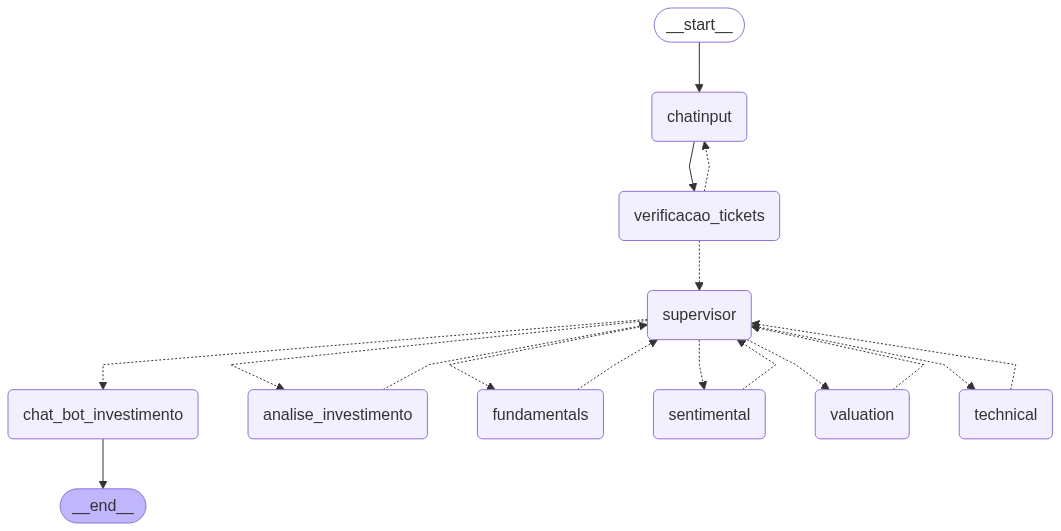

In [83]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Exception")
    pass

In [ ]:
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",

    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
   
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
 
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
   
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
   
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
   
    
    
    # Análises Técnicas Comparativas
    "Compare os indicadores técnicos da PETROBRAS e VALE",
    "Analise tecnicamente ITUB4, BBDC4 e BBAS3",
    "Qual ação tem melhor momento técnico: MGLU3, VIIA3 ou AMER3?",
    
    # Análises Fundamentalistas Comparativas
    "Compare os fundamentos de BBDC4 e ITUB4",
    "Qual tem melhores indicadores: VALE3 ou PETR4?",
    
    
    # Análises de Sentimento Comparativas
    "Compare o sentimento do mercado entre PETR4 e VALE3",
    "Qual banco tem melhor percepção: BBDC4, ITUB4 ou BBAS3?",
    
    
    # Análises de Valuation Comparativas
    "Compare o valor justo de PETR4 e VALE3",
    
    "Análise comparativa de preço justo: WEGE3 vs EMBR3",
    "Entre UGPA3 e CSAN3, qual está mais atrativa pelo valuation?",
    
    # Análises Setoriais Comparativas
    "Compare os principais bancos: BBDC4, ITUB4, BBAS3",
    
    "Análise do setor industrial: WEGE3, EMBR3, RAIL3",
    "Compare as empresas de mineração: VALE3, BRAP4, CSNA3",
    
    # Comparações Multi-análise
    "Compare PETR4 e VALE3 em termos técnicos e fundamentalistas",
    
    "Análise técnica, fundamental e sentimento: PETR4 vs VALE3",
    "Comparação completa entre os três maiores bancos",
    
    # Perguntas Específicas Comparativas
    "Qual é melhor para investir agora: PETR4 ou VALE3?",
    
    "Comparando risco-retorno, PETR4 ou VALE3?",
    "Qual banco oferece melhor oportunidade: BBDC4, ITUB4 ou BBAS3?"
]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

async def respondendo(user_input, config):
    for mess in user_input:
            # Configuração inicial do estado
        print('Pergunta feita:',mess)
        try:
            start = time.time()
            initial_state = {
                    "messages": [HumanMessage(content=mess)],
                    "ticker": "", 
                    "method_analysis": "" ,
                    "dados_input" : "",
                    "next" : ""
                    
                }
        
            events = await graph.ainvoke(
                    initial_state,
                    config=config,
                    stream_mode="values",
                )
            print('Pergunta feita:',mess)
            end = time.time()
            print(f'O tempo de execucao foi de {end - start}')
        except:
            print('Erro na execucao')
            pass    
    return events
    
respostas = await respondendo(user_input=user_input, config=config)   

In [85]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================== Ai Message ==================================

Bom dia! Estou bem, obrigado por perguntar. Estou aqui para ajudá-lo com suas dúvidas sobre investimentos e análise de dados. Como posso ajudá-lo hoje? Você tem alguma ação ou empresa específica em mente que gostaria de discutir? Lembre-se de que investimentos envolvem riscos e é importante avaliar cuidadosamente antes de tomar qualquer decisão.

================================ Human Message =================================

Olá, poderia me ajudar?

================================ Human Message =================================

Realize uma análise técnica da PETROBRAS

================================== Ai Message ==================================

Bom dia! Com base nos dados fornecidos, farei uma análise técnica da PETROBRAS (PETR4).

De acordo com os dados, a PETR4 apresenta uma tendência geral de

# Criando o Agente LangGraph

In [1]:
import sys
sys.path.append("..")
from typing import List, TypedDict
import operator

# Import message types from LangChain core messages.
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# Import StateGraph and special END node.
from langgraph.graph import StateGraph, END

# Define our state schema: all messages (chat history) will be collected here.
class TravelState(TypedDict):
    messages: List[BaseMessage]

In [2]:
import sys
sys.path.append("..")
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode 
from typing import Optional
import pandas as pd
from agente_investimento import DadosFundamentalistas
from agente_investimento import TratandoDadosValuationComparacao
from agente_investimento import DadosIndicadoresTecnicos

@tool
async def dados_fundamentalistas(tic: str, data_inicio: Optional[str] = None, data_fim: Optional[str] = None) -> pd.DataFrame:
        """ 
       Retrieve fundamental data for a specific ticker.

        Gets fundamental data for the specified period or defaults to last 4 periods
        if no start date is provided.

        Args:
            tic (str): Stock ticker symbol (ex: 'PETR4').
            data_inicio (str, optional): Start date in the format 'YYYY-MM-DD'. Defaults to None.
            data_fim (str, optional): End date in the format 'YYYY-MM-DD'. Defaults to None.

        Returns:
            pd.DataFrame: DataFrame containing fundamental data
        """
        df = DadosFundamentalistas(tic=tic, data_inicio=data_inicio, data_fim=data_fim)
        df_dados = await df.dados_fundamentalistas_completo()
        df_dados.reset_index(drop=True, inplace=True)
        return df_dados

@tool
async def dados_tecnicos(ticker: str, periodo: str = "5Y", intervalo: str = "1mo") -> pd.DataFrame:
    """
    Retrieves technical indicators data for a given asset.

    This asynchronous function collects technical data such as price, volume and indicators
    for technical analysis of a specific stock.

    Args:
        ticker (str): Stock symbol on B3 (e.g. 'PETR4')
        periodo (str, optional): Historical data period. Defaults to "5Y" (5 years).
            Accepted options:
            - "1d": 1 day
            - "5d": 5 days
            - "1mo": 1 month 
            - "3mo": 3 months
            - "6mo": 6 months
            - "1y": 1 year
            - "2y": 2 years
            - "5y": 5 years
            - "10y": 10 years
            - "ytd": Year to date
            - "max": Maximum history
        intervalo (str, optional): Interval between data points. Defaults to "1wk" (weekly).
            Accepted options:
            - "1m": 1 minute
            - "2m": 2 minutes 
            - "5m": 5 minutes
            - "15m": 15 minutes
            - "30m": 30 minutes
            - "60m": 60 minutes
            - "90m": 90 minutes
            - "1h": 1 hour
            - "1d": 1 day
            - "5d": 5 days
            - "1wk": 1 week
            - "1mo": 1 month
            - "3mo": 3 months

    Returns:
        pd.DataFrame: DataFrame containing the collected technical indicators

    Example:
        ```python
        data = await dados_tecnicos("PETR4", periodo="1Y", intervalo="1d")
        ```
    """
    ind_tecnicos = DadosIndicadoresTecnicos(ticker=ticker,periodo=periodo, intervalo=intervalo)
    df_dados = ind_tecnicos.pegando_indicadores_tecnicos()
    return df_dados


@tool
async def dados_valuation(tick: str) -> dict:
    
    """
    Retrieves valuation data for a given stock ticker.

    This asynchronous function calculates various valuation metrics including Gordon Growth Model valuation,
    Discounted Cash Flow valuation, and current market metrics.

    Args:
        tick (str): Stock ticker symbol (e.g., 'PETR4')

    Returns:
        dict: A dictionary containing four key elements:
            - Gordon Growth Model valuation table and calculated price
            - Projected cash flows table and DCF valuation 
            - Financial metrics used in calculations
            - Current market price

    Example:
        ```python
        valuation_data = await dados_valuation('PETR4')
        ```

    Output Format:
        The returned dictionary contains:
        1. Gordon Growth Model analysis with dividend data, growth rates, and price target
        2. Discounted cash flow projections for next 5 years with present values
        3. Key financial metrics like EBIT margin, revenue, WACC, debt levels etc.
        4. Current market price for comparison

    Note:
        The valuation calculations use various assumptions and should be used as one of multiple
        inputs in investment decisions, not as the sole decision factor.
    """

    trat = TratandoDadosValuationComparacao(tickers=[tick])

    valuation_preco = await trat.dados_valuation()

    return valuation_preco


from agente_investimento import TratarDadosNoticiasComparacao
import os


serper_api_key = os.getenv("SERPER_API_KEY")
api_secret_groq = os.getenv("GROQ_API_KEY")

@tool
async def dados_sentimento(ticker: str) -> str:
    """
    Retrieves and processes market sentiment data based on news for a specific stock.

    This asynchronous function uses external APIs (Serper and Groq) to collect and analyze
    recent news related to the specified ticker, generating a market sentiment analysis.

    Args:
        ticker (str): Stock ticker symbol (e.g., 'PETR4') for sentiment analysis

    Returns:
        str: Formatted string containing the sentiment analysis based on collected news,
            including headlines, summaries and overall market sentiment assessment

    Example:
        ```python
        sentiment_data = await dados_sentimento('PETR4')
        ```

    Notes:
        - Requires valid API keys for Serper and Groq configured as environment variables
        - The return may include multiple news items and their respective sentiment analyses
        - Function is asynchronous and must be called with await
    """
    trat_noticias = TratarDadosNoticiasComparacao(tickers=[ticker], 
                                              api_secret_serper=serper_api_key,
                                              api_secret_groq=api_secret_groq,
                                              options=None,)
    return await trat_noticias.tickes_news()
    

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
tools = [dados_fundamentalistas, dados_tecnicos, dados_valuation, dados_sentimento]
tool_node = ToolNode(tools)

In [4]:

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


#llm_with_tools = ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct").bind_tools(tools)

llm = ChatGroq(
    model="qwen-qwq-32b"
    #model="meta-llama/llama-4-maverick-17b-128e-instruct"
    )

empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )

empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])

template = """
        You are an investment analysis agent with over 10 years of experience. You receive the following data.
    
        Rules for ticker identification:
        - Brazilian tickers usually end with numbers 
        - If the user mentions only the company name (ex: "Petrobras"), identify the correct ticker from the list above
        - If there is ambiguity, prefer the most liquid ticker (usually ending in 3 or 4)
        Available Companies and Tickers:
        {empresas_tickers}

        Guidelines:
        - Be concise and direct
        - Use professional but accessible language
        - Acknowledge limitations when uncertain
        - Always mention investment risks
        - Avoid direct buy/sell recommendations

        Provide confidence level of analysis
        Indicate if, based on agent inputs, the recommendation is to buy, sell or hold the stock.

        ## Investment Analysis
        - Commentary on the asset

        ## Confidence Level
---

*Note:*  
If there is insufficient data about the company, respond normally based on a generic conversation.
IMPORTANT: ALWAYS PROVIDE THE RESPONSE IN PORTUGUESE (BRAZILIAN PORTUGUESE).

Question: {messages}
"""

prompt = ChatPromptTemplate.from_template(template)

llm_chain = prompt | llm.bind_tools(tools)


# Agora passe o input como um dicionário com a chave "messages"
response = llm_chain.invoke({
    "messages": "Como esta os fundamentos da unifique",
    "empresas_tickers": empresas_tickers
}).tool_calls

response

[{'name': 'dados_fundamentalistas',
  'args': {'data_fim': None, 'data_inicio': None, 'tic': 'FIQE3'},
  'id': '1envd79yg',
  'type': 'tool_call'}]

In [5]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver


def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    print(last_message.tool_calls)
    if last_message.tool_calls:
        return "tools"
    return END


# Define the function that calls the model
async def call_model(state: MessagesState):
    messages = state["messages"]
    #response = await llm_with_tools.ainvoke(messages)
    response = await llm_chain.ainvoke({"messages": messages,
                                    "empresas_tickers": empresas_tickers})
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, ["tools", END])
workflow.add_edge("tools", "agent")

memory = MemorySaver()
#app = workflow.compile(checkpointer=memory)
app = workflow.compile()

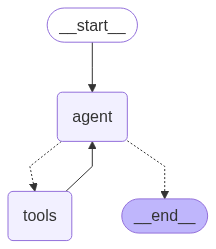

In [6]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [7]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

inputs = {"messages": [HumanMessage(content="Quem tem o melhor sentimento do mercado entre vale e petrobras?")]}
response = await app.ainvoke(inputs,
                             #config=config
                             )

[{'name': 'dados_sentimento', 'args': {'ticker': 'VALE3'}, 'id': 'mx55gz68y', 'type': 'tool_call'}, {'name': 'dados_sentimento', 'args': {'ticker': 'PETR3'}, 'id': 'y1hyc7kxg', 'type': 'tool_call'}, {'name': 'dados_sentimento', 'args': {'ticker': 'PETR4'}, 'id': 'n7dtgafbe', 'type': 'tool_call'}]
Error fetching URL: Client error '403 Forbidden' for url 'https://br.advfn.com/follow-feed/card/noticias-BOV-PETR3-74884eb87160d18e7791cb38ccccc38d'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: Client error '403 Forbidden' for url 'https://acionista.com.br/petrobras-petr4-pode-estar-prestes-a-surpreender-prepare-se/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: Client error '403 Forbidden' for url 'https://br.advfn.com/noticias/BOV/2025/artigo/96397899'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
[]


In [8]:
response['messages'][-1].content.split("\n\n")

['<answer>\n<p>\n<strong>Análise de Sentimento do Mercado:</strong>\n<br/>\n- <strong>VALE3</strong> apresenta sinalização positiva com alta de 3,88% impulsionada pelo preço do minério de ferro atingindo US$ 100, além de expectativa de lucro expressivo.\n<br/>\n- <strong>PETR3/PETR4</strong> destacam dividendos atrativos (yield ~9%), recomendações de analistas e pagamento de proventos, porém com ressalva sobre estrutura de capital.\n</p>',
 '<p>\n<strong>Comparação:</strong>\n<br/>\nVALE3 tem maior impulso técnico no curto prazo (preço do minério), enquanto PETR tem vantagem em proventos e recomendações setoriais. \n</p>',
 '<p>\n<strong>Recomendação: HOLD</strong>\n<br/>\n<em>Mantendo posição neutra por igualdade de fundamentos: VALE3 com vantagem cíclica e PETR3/4 com vantagem distributiva. Riscos: volatilidade de commodities para VALE e incertezas regulatórias para PETR.</em>\n</p>',
 '<p>\n<strong>Nível de Confiança:</strong> Médio-Alto (baseado em notícias recentes, mas sem dados 

In [9]:
response['messages']

[HumanMessage(content='Quem tem o melhor sentimento do mercado entre vale e petrobras?', additional_kwargs={}, response_metadata={}, id='97031d7d-cafe-4897-8ef1-8694fb008cd5'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'mx55gz68y', 'function': {'arguments': '{"ticker":"VALE3"}', 'name': 'dados_sentimento'}, 'type': 'function'}, {'id': 'y1hyc7kxg', 'function': {'arguments': '{"ticker":"PETR3"}', 'name': 'dados_sentimento'}, 'type': 'function'}, {'id': 'n7dtgafbe', 'function': {'arguments': '{"ticker":"PETR4"}', 'name': 'dados_sentimento'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 392, 'prompt_tokens': 2159, 'total_tokens': 2551, 'completion_time': 0.89945965, 'prompt_time': 0.130211025, 'queue_time': 0.286807032, 'total_time': 1.029670675}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_ea798e78f0', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--3fc1dec4-c18a-456d-b13e-90d409fc8c1d-0', tool_calls=[{'name': 

# Adcionando outros chatbots

In [10]:
import sys
sys.path.append("..")
from typing import List, TypedDict
import operator
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

# Import message types from LangChain core messages.
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# Import StateGraph and special END node.
from langgraph.graph import StateGraph, END

# Define our state schema: all messages (chat history) will be collected here.
class TravelState(TypedDict):
    messages: List[BaseMessage]

In [13]:
import sys
sys.path.append("..")
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode 
from typing import Optional
import pandas as pd
from langchain_core.documents import Document
from agente_investimento import TratandoDadosValuationComparacao
from agente_investimento import DadosIndicadoresTecnicos
from agente_investimento import TratarDadosNoticiasComparacao
from agente_investimento import TratatandoDadosFundamentalistasComparacao
import os

@tool
async def dados_fundamentalistas(tic: str, 
                                 data_inicio: Optional[str] = "2024-01-01", 
                                 data_fim: Optional[str] = None,
                                 ) -> List[List[Document]]:
        """ 
       Retrieve fundamental data for a specific ticker.

        Gets fundamental data for the specified period or defaults to last 4 periods
        if no start date is provided.

        Args:
            tic (str): Stock ticker symbol (ex: 'PETR4').
            data_inicio (str, optional): Start date in the format 'YYYY-MM-DD'. Defaults to '2024-01-01'.
            data_fim (str, optional): End date in the format 'YYYY-MM-DD'. Defaults to None.

        Returns:
            LIST of Documents: List containing fundamental data
        """

        df = TratatandoDadosFundamentalistasComparacao(tics=[tic], data_inicio=data_inicio, data_fim=data_fim)
        df_dados = await df.coletando_dados_tickers()
        return df_dados

@tool
async def dados_tecnicos(ticker: str, periodo: str = "5Y", intervalo: str = "1mo") -> pd.DataFrame:
    """
    Retrieves technical indicators data for a given asset.

    This asynchronous function collects technical data such as price, volume and indicators
    for technical analysis of a specific stock.

    Args:
        ticker (str): Stock symbol on B3 (e.g. 'PETR4')
        periodo (str, optional): Historical data period. Defaults to "5Y" (5 years).
            Accepted options:
            - "1d": 1 day
            - "5d": 5 days
            - "1mo": 1 month 
            - "3mo": 3 months
            - "6mo": 6 months
            - "1y": 1 year
            - "2y": 2 years
            - "5y": 5 years
            - "10y": 10 years
            - "ytd": Year to date
            - "max": Maximum history
        intervalo (str, optional): Interval between data points. Defaults to "1wk" (weekly).
            Accepted options:
            - "1m": 1 minute
            - "2m": 2 minutes 
            - "5m": 5 minutes
            - "15m": 15 minutes
            - "30m": 30 minutes
            - "60m": 60 minutes
            - "90m": 90 minutes
            - "1h": 1 hour
            - "1d": 1 day
            - "5d": 5 days
            - "1wk": 1 week
            - "1mo": 1 month
            - "3mo": 3 months

    Returns:
        pd.DataFrame: DataFrame containing the collected technical indicators

    Example:
        ```python
        data = await dados_tecnicos("PETR4", periodo="1Y", intervalo="1d")
        ```
    """
    ind_tecnicos = DadosIndicadoresTecnicos(ticker=ticker,periodo=periodo, intervalo=intervalo)
    df_dados = ind_tecnicos.pegando_indicadores_tecnicos()
    return df_dados


@tool
async def dados_valuation(tick: str) -> dict:
    
    """
    Retrieves valuation data for a given stock ticker.

    This asynchronous function calculates various valuation metrics including Gordon Growth Model valuation,
    Discounted Cash Flow valuation, and current market metrics.

    Args:
        tick (str): Stock ticker symbol (e.g., 'PETR4')

    Returns:
        dict: A dictionary containing four key elements:
            - Gordon Growth Model valuation table and calculated price
            - Projected cash flows table and DCF valuation 
            - Financial metrics used in calculations
            - Current market price

    Example:
        ```python
        valuation_data = await dados_valuation('PETR4')
        ```

    Output Format:
        The returned dictionary contains:
        1. Gordon Growth Model analysis with dividend data, growth rates, and price target
        2. Discounted cash flow projections for next 5 years with present values
        3. Key financial metrics like EBIT margin, revenue, WACC, debt levels etc.
        4. Current market price for comparison

    Note:
        The valuation calculations use various assumptions and should be used as one of multiple
        inputs in investment decisions, not as the sole decision factor.
    """

    trat = TratandoDadosValuationComparacao(tickers=[tick])

    valuation_preco = await trat.dados_valuation()

    return valuation_preco



serper_api_key = os.getenv("SERPER_API_KEY")
api_secret_groq = os.getenv("GROQ_API_KEY")

@tool
async def dados_sentimento(ticker: str) -> str:
    """
    Retrieves and processes market sentiment data based on news for a specific stock.

    This asynchronous function uses external APIs (Serper and Groq) to collect and analyze
    recent news related to the specified ticker, generating a market sentiment analysis.

    Args:
        ticker (str): Stock ticker symbol (e.g., 'PETR4') for sentiment analysis

    Returns:
        str: Formatted string containing the sentiment analysis based on collected news,
            including headlines, summaries and overall market sentiment assessment

    Example:
        ```python
        sentiment_data = await dados_sentimento('PETR4')
        ```

    Notes:
        - Requires valid API keys for Serper and Groq configured as environment variables
        - The return may include multiple news items and their respective sentiment analyses
        - Function is asynchronous and must be called with await
    """
    trat_noticias = TratarDadosNoticiasComparacao(tickers=[ticker], 
                                              api_secret_serper=serper_api_key,
                                              api_secret_groq=api_secret_groq,
                                              options=None,)
    return await trat_noticias.tickes_news()
    

## chat bot fundamentalista

In [15]:
## chat bot fundamentalista
querry = "Qual da acoes tem o melhor fundamento fundamentos da PETR4, BBDC4, ITUB4?"

tools_fundamentalista = [dados_fundamentalistas]

tool_node_fundamentalista = ToolNode(tools_fundamentalista)

prompt_fundamentalista = """
Você é um assistente especializado em investimentos do mercado brasileiro. 
Sua tarefa é analisar os dados fundamentalistas de uma ação específica responder a pergunta {messages} do usuario.
Para isso, você deve utilizar a ferramenta de dados fundamentalistas fornecida a voce.
Use os dados retornados pela ferramenta para basear sua análise.
Seja objetivo e claro em suas respostas, fornecendo informações relevantes sobre a empresa,
seus indicadores financeiros e perspectivas de investimento.
A sua resposta deve ter no máximo 100 palavras.

Limitações:
1. Você não deve fornecer recomendações de compra ou venda de ações.
2. Se não houver informações suficientes sobre a empresa, informe que não é possível realizar a análise.

Question: {messages}
"""

prompt_fundamentalista = ChatPromptTemplate.from_template(prompt_fundamentalista)

llm_fundamentalista = ChatGroq(
    model="deepseek-r1-distill-llama-70b",
    temperature=0,
    stop_sequences=None
)

llm_chain_fundamentalista = prompt_fundamentalista | llm_fundamentalista.bind_tools(tools_fundamentalista)

# Agora passe o input como um dicionário com a chave "messages"
response = llm_chain_fundamentalista.invoke({
    "messages": "Qual da acoes tem o melhor fundamento fundamentos da PETR4, BBDC4, ITUB4??",
    
}).tool_calls


In [16]:
response

[{'name': 'dados_fundamentalistas',
  'args': {'tic': 'PETR4'},
  'id': 'w3mw164fj',
  'type': 'tool_call'}]

In [17]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver


class TravelStateFundamentalista(TypedDict):
    messages: List[BaseMessage]


def should_continue_fundamentalista(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    #print(last_message.tool_calls)
    if last_message.tool_calls:
        return "tools_fundamentalista"
    return END


# Define the function that calls the model
async def call_model_fundamentalista(state: MessagesState):
    messages = state["messages"]
    #response = await llm_with_tools.ainvoke(messages)
    response = await llm_chain_fundamentalista.ainvoke({"messages": messages,})
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


workflow_fundamentalista = StateGraph(MessagesState)

workflow_fundamentalista.add_node("agente_fundamentalista", call_model_fundamentalista)
workflow_fundamentalista.add_node("tools_fundamentalista", tool_node_fundamentalista)

workflow_fundamentalista.add_edge(START, "agente_fundamentalista")
workflow_fundamentalista.add_conditional_edges("agente_fundamentalista", should_continue_fundamentalista, ["tools_fundamentalista", END])
workflow_fundamentalista.add_edge("tools_fundamentalista", "agente_fundamentalista")

graph_fundametalista = workflow_fundamentalista.compile()

In [ ]:
response = await graph_fundametalista.ainvoke({"messages": "Entre PETR4, BBDC4  qual tem o melhor fundamento"})

In [19]:
response['messages'][3].content.split("\n\n")

['',
 'PETR4 apresenta margens de lucro líquido variáveis, com destaque para o trimestre de setembro de 2024, onde atingiu 16,8%. A dívida líquida tem aumentado, passando de R$ 251 milhões para R$ 353 milhões, indicando maior alavancagem financeira. O preço/lucro está em 5,47, mostrando valorização moderada. BBDC4 não teve dados disponíveis para comparação.']

In [21]:
response['messages']

[HumanMessage(content='Entre PETR4, BBDC4  qual tem o melhor fundamento', additional_kwargs={}, response_metadata={}, id='92e0d127-37bd-4a64-a1ef-ac745b6d2d93'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qjzxcvvmw', 'function': {'arguments': '{"tic":"PETR4"}', 'name': 'dados_fundamentalistas'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 566, 'total_tokens': 616, 'completion_time': 0.181818182, 'prompt_time': 0.036772596, 'queue_time': 0.27792295100000003, 'total_time': 0.218590778}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_76307ac09b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--700269f5-6e3e-4540-844a-39d3a3c830d1-0', tool_calls=[{'name': 'dados_fundamentalistas', 'args': {'tic': 'PETR4'}, 'id': 'qjzxcvvmw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 566, 'output_tokens': 50, 'total_tokens': 616}),
 ToolMessage(content="[[Document(metadata={'receit

## Chat bot analise tecnica

In [22]:
## chat bot fundamentalista
querry = "Quero análise tecnica da PETR4"

tools_tecnicos = [dados_tecnicos]

tool_node_tecnicos = ToolNode(tools_tecnicos)

prompt_tecnicos = """
Você é um assistente especializado em investimentos do mercado brasileiro. 
Sua tarefa é analisar os dados tecnicos de uma ação específica responder a pergunta {messages} do usuario.
Para isso, você deve utilizar a ferramenta de dados fundamentalistas fornecida a voce.
Use os dados retornados pela ferramenta para basear sua análise.
Seja objetivo e claro em suas respostas, fornecendo informações relevantes sobre a empresa,
seus indicadores financeiros e perspectivas de investimento.
A sua resposta deve ter no máximo 200 palavras.

Limitações:
1. Você não deve fornecer recomendações de compra ou venda de ações.
2. Se não houver informações suficientes sobre a empresa, informe que não é possível realizar a análise.

Question: {messages}
"""

prompt_tecnicos = ChatPromptTemplate.from_template(prompt_tecnicos)

llm_tecnicos = ChatGroq(
    model="meta-llama/llama-4-maverick-17b-128e-instruct",
    temperature=0,
    stop_sequences=None
)

llm_chain_tecnicos = prompt_tecnicos | llm_tecnicos.bind_tools(tools_tecnicos)

# Agora passe o input como um dicionário com a chave "messages"
response_tecnicos = llm_chain_tecnicos.invoke({
    "messages": "Como esta analise tecnica da petr4?",
    
}).tool_calls


In [23]:
response_tecnicos

[{'name': 'dados_tecnicos',
  'args': {'intervalo': '1d', 'periodo': '1Y', 'ticker': 'PETR4'},
  'id': '4h2p0b6p8',
  'type': 'tool_call'}]

In [24]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver


class TravelStateTecnicos(TypedDict):
    messages: List[BaseMessage]


def should_continue_tecnicos(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools_tecnicos"
    return END


# Define the function that calls the model
async def call_model_tecnicos(state: MessagesState):
    messages = state["messages"]
    response = await llm_chain.ainvoke({"messages": messages,
                                    "empresas_tickers": empresas_tickers})
    return {"messages": [response]}


workflow_tecnicos = StateGraph(MessagesState)

workflow_tecnicos.add_node("agente_tecnicos", call_model_tecnicos)
workflow_tecnicos.add_node("tools_tecnicos", tool_node_tecnicos)

workflow_tecnicos.add_edge(START, "agente_tecnicos")
workflow_tecnicos.add_conditional_edges("agente_tecnicos", should_continue_tecnicos, ["tools_tecnicos", END])
workflow_tecnicos.add_edge("tools_tecnicos", "agente_tecnicos")

graph_tecnicos = workflow_tecnicos.compile()

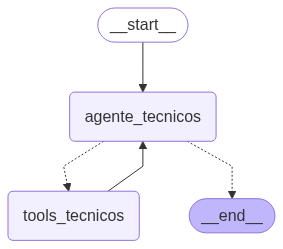

In [34]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(graph_tecnicos.get_graph().draw_mermaid_png()))
except Exception:
    print("Exception")
    pass

In [50]:
response = await graph_tecnicos.ainvoke({"messages": "Como esta analise tecnica da petr4?"})

In [63]:
len(texto_final)

11622

## Chat principal

In [118]:

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


#llm_with_tools = ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct").bind_tools(tools)

llm = ChatGroq(
    model="qwen-qwq-32b"
    #model="meta-llama/llama-4-maverick-17b-128e-instruct"
    )

empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )

empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])

template = """
        You are an investment analysis agent with over 10 years of experience. You receive the following data.
    
        Rules for ticker identification:
        - Brazilian tickers usually end with numbers 
        - If the user mentions only the company name (ex: "Petrobras"), identify the correct ticker from the list above
        - If there is ambiguity, prefer the most liquid ticker (usually ending in 3 or 4)
        Available Companies and Tickers:
        {empresas_tickers}

        Guidelines:
        - Be concise and direct
        - Use professional but accessible language
        - Acknowledge limitations when uncertain
        - Always mention investment risks
        - Avoid direct buy/sell recommendations

        Provide confidence level of analysis
        Indicate if, based on agent inputs, the recommendation is to buy, sell or hold the stock.

        ## Investment Analysis
        - Commentary on the asset

        ## Confidence Level
---

*Note:*  
If there is insufficient data about the company, respond normally based on a generic conversation.
IMPORTANT: ALWAYS PROVIDE THE RESPONSE IN PORTUGUESE (BRAZILIAN PORTUGUESE).

Question: {messages}
"""

prompt = ChatPromptTemplate.from_template(template)

from pydantic import BaseModel, Field

class TICKS(BaseModel):
    "Rule for ticker identification:"
    empresas_tickers: List[str] = Field(..., description="Return so the tickers")

llm_chain = prompt | llm.with_structured_output(TICKS)





In [129]:

response = llm_chain.invoke({"messages": "Como esta os fundamentos da petr4, vale e itausa, banco do brasil, bradesco, b3, mARCOPOLO?",
                  "empresas_tickers": empresas_tickers})

In [130]:
response.empresas_tickers

['PETR4', 'VALE3', 'ITSA3', 'BBAS3', 'BBDC3', 'B3SA3', 'MARC4']

In [52]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition

from typing import Literal

# Opção 1: Baseado em tool calls específicos
def should_continue(state: MessagesState) -> Literal["agente_fundamentalista", "agente_tecnicos", END]:
    """
    Roteia baseado nos tool calls da última mensagem
    """
    messages = state["messages"]
    last_message = messages[-1]
    
    # Se não há tool calls, finaliza
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return END
    
    # Verifica qual ferramenta foi chamada
    for tool_call in last_message.tool_calls:
        tool_name = tool_call.get('name', '')
        
        # Roteamento baseado no nome da ferramenta
        if 'fundamental' in tool_name.lower() or 'dados_fundamentalistas' in tool_name:
            return "agente_fundamentalista"
        elif 'tecnico' in tool_name.lower() or 'analise_tecnica' in tool_name:
            return "agente_tecnicos"
    
    # Se nenhuma ferramenta específica, finaliza
    return END



# Define the function that calls the model
async def call_model(state: MessagesState):
    messages = state["messages"]
    #response = await llm_with_tools.ainvoke(messages)
    response = await llm_chain.ainvoke({"messages": messages,
                                    "empresas_tickers": empresas_tickers})
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


workflow = StateGraph(MessagesState)

workflow.add_node("agente_principal", call_model)
workflow.add_node("agente_fundamentalista", graph_fundametalista)
workflow.add_node("agente_tecnicos", graph_tecnicos)

workflow.add_edge(START, "agente_principal")
workflow.add_conditional_edges(
    "agente_principal",
    should_continue,
    {
        "agente_fundamentalista": "agente_fundamentalista",
        "agente_tecnicos": "agente_tecnicos",
        END: END,
    }
)
workflow.add_edge("agente_fundamentalista", "agente_principal")
workflow.add_edge("agente_tecnicos", "agente_principal")


#workflow.add_edge("agente_principal", END)

memory = MemorySaver()
#app = workflow.compile(checkpointer=memory)
app = workflow.compile()

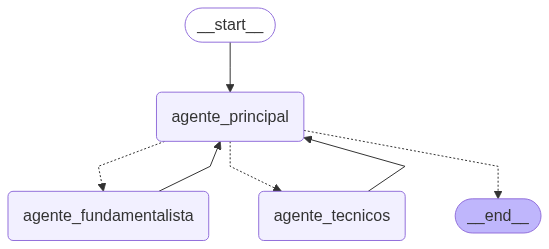

In [53]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Exception")
    pass

In [58]:
response = await app.ainvoke({"messages": "Como esta os fundamentos da petr4?"})

# Chat bot

In [1]:
from typing import Annotated, TypedDict, Literal
from langgraph.graph.message import add_messages
from typing import List
class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: List[str]
    method_analysis: List[str]  
    interacao_procura_ticker: int
    next_method: str
    mensagem_sistema: str
    dados_input: str

In [2]:
import pandas as pd
from typing import List
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage
from pydantic import BaseModel, Field

# Supondo que seu estado seja um dicionário. Se for uma classe, o acesso será similar.
# from typing_extensions import TypedDict
# class STATE(TypedDict):
#     messages: list
#     ticker: List[str]

# 1. Inicialização do LLM (sugestão de um modelo mais robusto)
llm = ChatGroq(
    # Modelos maiores como o Llama 3 70B costumam seguir instruções melhor
    model="llama3-70b-8192",
    # model="qwen-qwq-32b" # Seu modelo original
)

# 2. Carregamento dos dados das empresas
empresas_df = pd.read_csv(
    "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
    encoding="utf-8",
)

# 3. Criação da lista de tickers para o prompt
empresas_tickers = "\n".join(
    [f"{empresa} ({ticker})" for empresa, ticker in zip(empresas_df['Empresa'], empresas_df['tic'])]
)

# 4. Template de Prompt Aprimorado
template = """
You are an expert investment analysis agent. Your task is to identify all relevant stock tickers from the user's query.

Here is a list of available Brazilian companies and their corresponding tickers:
---
{empresas_tickers}
---

Based on the list above, identify ALL stock tickers mentioned in the user's query below.

Rules for ticker identification:
- Brazilian tickers usually end with a number (e.g., 3, 4, 11).
- If the user mentions only the company name (e.g., "Petrobras"), find the correct ticker from the list.
- If a company has multiple tickers, prefer the most liquid one, which typically ends in 3 (common stock) or 4 (preferred stock).
- You must return every ticker you identify. For example, if the user asks about "Petrobras e Vale", you must return both 'PETR4' and 'VALE3'.
- If no relevant tickers are found in the query, return an empty list.

User Query: "{messages}"
"""

prompt = ChatPromptTemplate.from_template(template)

# 5. Modelo Pydantic mais claro e específico
class Tickers(BaseModel):
    """A list of identified stock tickers."""
    tickers: List[str] = Field(
        ...,
        description="A list of stock tickers identified from the user's message. For example: ['PETR4', 'VALE3']"
    )

# 6. Chain com o LLM e o output estruturado
llm_identifica_ticker = prompt | llm.with_structured_output(Tickers)

# 7. Função para o nó do grafo, agora mais robusta
def identifica_ticks(state: State):# Command[Literal["chatinput", "roteador_analise"]]:
    """
    Identifies stock tickers from the last message in the state and updates the 'ticker' key.
    """
    print('Entrei identificacao ticks')
    messages = state.get('messages', [])

    if not messages:
        return {"ticker": []}  # Retorna lista vazia se não houver mensagens
    

    # Invoca a chain para identificar os tickers
    resposta_ticker = llm_identifica_ticker.invoke({
        "messages": messages,
        "empresas_tickers": empresas_tickers
    })
    return {'ticker': resposta_ticker.tickers}



In [3]:
class MetodoAnalise(BaseModel):
    """A list of stock Analysis methods."""
    method_analysis: List[Literal['fundamentalista', 'tecnico', 'sentimento', 'valuation', 'sem_analise']] = Field(
        ...,
        description="A list of method analysis identified from the user's message. For example: ['fundamentalista', 'valuation']"
    )

prompt_metodo_analise = """
You are an expert investment analysis agent. Your task is to identify the analysis method from the user's query.

Available analysis methods:
- fundamentalista
- tecnico
- sentimento
- valuation

If the user's query does not match any of the available methods, return 'sem_analise'.

User Query: "{messages}"
"""
prompt_metodo_analise = ChatPromptTemplate.from_template(prompt_metodo_analise)

llm_identifica_metodo_analise = prompt_metodo_analise | llm.with_structured_output(MetodoAnalise)

In [4]:
from langgraph.types import Command
def identifica_metodo_analise(state: State) -> Command[Literal["identifica_ticks", "chatbot_padrao"]]:
    """
    Identifies stock tickers from the last message in the state and updates the 'ticker' key.
    """
    print('Entrei no identifica_metodo_analise')
    messages = state.get('messages', [])
    if not messages:
        return {"method_analysis": []}  # Retorna lista vazia se não houver mensagens
    # Invoca a chain para identificar os tickers
    resposta_metodo_analise = llm_identifica_metodo_analise.invoke({"messages": messages})
    
    
    
    if 'sem_analise' in resposta_metodo_analise.method_analysis :
        return Command(
        goto="chatbot_padrao",
        update={"mensagem_sistema": "O usuario nao informou nenhum metodo de analise## Essa foi a pergunta feita pelo usuario:{messages}"}
    ) 
    return Command(
        goto="identifica_ticks",
        update={'method_analysis': resposta_metodo_analise.method_analysis})


In [5]:
from typing_extensions import Literal
from langgraph.types import Command

def verificacao_tickets(state: State) -> Command[Literal["identifica_ticks", "supervisor", "chatbot_padrao"]]:
    """
    Checks whether the extracted ticker is valid or if the analysis method corresponds to the chatbot.

    This function performs a check on the current state to determine whether the provided ticker
    is present in the list of valid companies (loaded from an external source) or if the analysis
    method includes 'chatbot'. Based on this, it decides whether the flow should proceed
    to the supervisor node or return to the user input node.

    Args:
        state (State): The current state dictionary, containing at least the keys
                       'ticker' (str) and 'method_analysis' (list).

    Returns:
        Command[Literal["chatinput", "supervisor"]]: A command indicating the next node
            to be executed in the flow:
            - "supervisor" if the ticker is valid or the analysis method is 'chatbot'.
            - "chat_input" otherwise, indicating that the user input should be revised.
    """
    print('Entrei verificacao tickets')
    
    ticker = state.get("ticker", "")
    
    mensagem = state.get("messages")
    
    last_messagem = mensagem[-1]
    
    procura_interacao_ticker = state.get('interacao_procura_ticker', 0)
    
    empresas_df = pd.read_csv(
        "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv",
        encoding="utf-8",
    )
    
    if isinstance(ticker, list):
        ticker = [tick for tick in ticker if tick in empresas_df['tic'].values]
    if isinstance(ticker,str):
        ticker = ticker in empresas_df["tic"].values
    if ticker:
        return Command(
            goto="supervisor",
        )
        
    if procura_interacao_ticker >=2:
        print(f"As ações nao foram encontrados!")
        return Command(
            goto="chatbot_padrao",
            update={
                'mensagem_sistema': f"As ações nao foram encontrados!## Essa foi a pergunta feita pelo usuario:{last_messagem}",
                'interacao_procura_ticker': 0}
        )
        
    procura_interacao_ticker += 1 
      
    return Command(
        goto="identifica_ticks",
        update={'interacao_procura_ticker': procura_interacao_ticker}
    ) 
    
    

In [6]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command

# Defina os métodos de análise disponíveis
members = ['fundamentalista', 'tecnico', 'sentimento', 'valuation','analise_investimento']
options = members + ["FINISH"]

system_prompt = (
    "Você é um supervisor de análise de investimentos. Sua tarefa é gerenciar "
    f"os seguintes métodos de análise: {members}. Dada a solicitação do usuário, "
    "decida qual próximo método de análise deve ser executado. Cada método "
    "realizará sua análise específica e reportará resultados. Quando todas "
    "as análises necessárias estiverem concluídas, responda com FINISH."
)

class Router(TypedDict):
    """Determina o próximo método de análise. Se nenhum método for necessário, encerra."""
    next: Literal['fundamentalista', 'tecnico', 'sentimento', 'valuation','analise_investimento', 'FINISH']


llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    stop_sequences=None,
)
        

def supervisor_node(state: State) -> Command[Literal['fundamentalista', 'tecnico', 'sentimento', 'valuation','analise_investimento', 'chatbot_investimento']]:
    print('Entrei no supervisor')
    
    # Se não houver mais métodos de análise, vá para o chatbot
    if not state['method_analysis']:
        print("Todos os métodos de análise concluídos")
        return Command(
            goto="chatbot_investimento"
        )

    messages = [{"role": "system", "content": system_prompt},] + state['method_analysis']

    # Adiciona contexto sobre os métodos disponíveis
    context_message = (
        f"Métodos de análise disponíveis: {', '.join(state['method_analysis'])}. "
        "Escolha o próximo método a ser executado."
    )
    messages.append({"role": "system", "content": context_message})


    try:
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
    except Exception as e:
        print(f"Erro na seleção do método: {e}")
        # Caso de erro, use o primeiro método disponível
        goto = state['method_analysis'][0]
    
    # Se o método selecionado não está na lista de métodos restantes, 
    # escolha o primeiro disponível
    if goto not in state['method_analysis']:
        goto = state['method_analysis'][0]

    # Remover o método selecionado da lista de métodos
    remaining_methods = [m for m in state['method_analysis'] if m != goto]
    
    return Command(
        goto=goto,
        update={
    
            "method_analysis": remaining_methods,
            "next_method": goto
        }
    )


In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

def chatbot_padrao(state:State):
    print('Entrei no chatbot_padrao')
    
    mensagem_sistema = state.get('mensagem_sistema', None)
    
    template_padrao = (
        """Voce faz parte de um chatbot de investimentos. Voce cuida de responder as perguntas do usuario que nao podem ser respondidas pelo agente principal.
        Voce cuida das saudacoes, e se não for encontrados os ticker das açoes de uma resposta indicando que nao foi encontrado.
        Sera informado qual foi a questao atraves de uma mensagem do sistema {mensagem_sistema}.
        Sempre responda educadamente e em portugues.
        """
    )
    
    chat_prompt = ChatPromptTemplate.from_template(template_padrao)
    
    llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0, stop_sequences=None, max_tokens=500)
    
    llm_chain = chat_prompt | llm | StrOutputParser()
    
    response = llm_chain.invoke({
        "mensagem_sistema": mensagem_sistema}
    )
    
    return {
            "messages": [AIMessage(content=response)],
        
        }

In [9]:
from typing import Any, Dict

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

import sys
sys.path.append("..")
from agente_investimento import get_llm
from agente_investimento import State

from typing import Final

from dotenv import load_dotenv
import os

load_dotenv()

DEFAULT_MODEL: Final = "meta-llama/llama-4-scout-17b-16e-instruct"

MODEL_ID_CHAT_RESPONSE: str = os.getenv("MODEL_ID_CHAT_RESPONSE", DEFAULT_MODEL)


async def chatbot_investimento(state: State) -> Dict[str, Any]:
    """
    Generates a consolidated investment analysis response using an LLM.

    This function builds a detailed prompt for an LLM (ChatGroq),
    providing it with the results of previous analyses (technical, fundamental,
    sentiment, valuation) stored in `state['dados_input']` and the user's latest
    message from `state['messages']`.

    The LLM is instructed to act as an investment assistant, summarize
    each type of analysis, provide an overall commentary on the asset,
    indicate a confidence level, and give final considerations (including risks),
    formatting the output in Markdown.

    Args:
        state (State): The current state dictionary, which must include:
            - 'dados_input': A list of strings, each representing the result
                             of a previous analysis, separated by specific markers
                             (e.g., '###Technical Analysis###').
            - 'messages': A list of conversation messages, where the last
                          one is the most recent user query.
            - 'ticker': (Optional) The stock ticker being analyzed.
            - 'method_analysis': (Optional) The identified analysis method.

    Returns:
        Dict[str, Any]: A dictionary containing the new AI message ('messages'),
                        and preserving 'ticker', 'method_analysis', and 'dados_input'
                        from the original state. In case of processing errors,
                        the AI message will include an error description.
    """

    try:
        system_message = SystemMessage(
            content=f"""
        You are an investment analysis agent with over 10 years of experience. You receive the following data.        
        <INPUT DATA>
        {state["dados_input"]}.
        </INPUT DATA>
        Your task is to analyze the data and answer the user's question {state["messages"]}.

        Guidelines:
        - Be concise and direct
        - Use professional but accessible language  
        - Acknowledge limitations when uncertain
        - Always mention investment risks
        - Avoid direct buy/sell recommendations

        ## Investment Analysis
        - Comment on why you think the stock is good

        *Note:*  
        If there is insufficient data about the company, respond normally based on a generic conversation.
        IMPORTANT: ALWAYS PROVIDE THE RESPONSE IN PORTUGUESE (BRAZILIAN PORTUGUESE).
        
        """
        )

        last_message = state["messages"][-1]

        messages = [system_message, HumanMessage(content=f"{last_message.content}")]

        llm = get_llm(model=MODEL_ID_CHAT_RESPONSE)

        response = await llm.ainvoke(messages)

        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get("dados_input", ""),
        }

    except Exception as e:  # pylint: disable=W0718
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": "",
        }
        

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [10]:
from agente_investimento import ModeloFundamentosComparacaoAsync
from agente_investimento import ModeloAnaliseTecnicaComparacao
from agente_investimento import ModeloValuationComparacao
from agente_investimento import ModeloSentimentoComparacao

async def process_fundamental(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise fundamentalista para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloFundamentosComparacaoAsync(tickers=tickers, query=query)
    response = await modelo.chat_fundamentalistas_comparacao()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="fundamental")
            ]
        },
        goto="supervisor",
        )
    

async def process_technical(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise tecnica para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos tecnica comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloAnaliseTecnicaComparacao(tickers=tickers, query=query, periodo="3Y", intervalo="1mo",)
    response = await modelo.chat_analise_tecnica_comparacao()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="technical")
            ]
        },
        goto="supervisor",
        )
    
    
async def process_valuation(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise valuation para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos comparacao')
    
    tickers = state['ticker']
    query = state["messages"][-1]

    modelo = ModeloValuationComparacao(query=query,tickers=tickers)

    response = await modelo.chat_valuation()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    
    
async def process_sentimento(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a comparação de análise de sentimento para os tickers especificados no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos sentimentos comparacao')

    
    tickers = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloSentimentoComparacao(tickers=tickers, query=query)
    response = await modelo.chat_sentimento()
    dados_input = state.get('dados_input', '')
    if dados_input:
        response = f"{dados_input}\n{response}"
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="sentimento")
            ]
        },
        goto="supervisor",
        )
    
    
async def analise_investimento(state: State) -> Command[Literal["supervisor"]]:
    
    """
    Executes fundamental analysis, valuation analysis, technical analysis and sentiment analysis for the specified ticker in the state.

    Retrieves the ticker and the user's last message from the state.
    Instantiates and calls the asynchronous fundamental analysis model.
    Adds the model's response to the 'dados_input' list in the state.

    Args:
        state (State): The current state dictionary, containing 'ticker',
                       'messages', and 'dados_input'.

    Returns:
        Optional[State]: The updated state with the fundamental analysis response
                         added to 'dados_input', or None if an error occurs.
    """
    
    print('Entrei em analise investimento comparacao')
    tickers = state['ticker']
    
    query = state["messages"][-1]
    
    dados_input = state.get('dados_input', '')
    

    tecnica = ModeloAnaliseTecnicaComparacao(
        query=query,
        tickers=tickers,
    )
    fundamentos = ModeloFundamentosComparacaoAsync(
        query=query,
        tickers=tickers,
    )
    valuation = ModeloValuationComparacao(
        query=query,
        tickers=tickers,
    )
    sentimento = ModeloSentimentoComparacao(
        query=query,
        tickers=tickers,
    )

    response = await asyncio.gather(
        tecnica.chat_analise_tecnica_comparacao(),
        fundamentos.chat_fundamentalistas_comparacao(),
        valuation.chat_valuation(),
        sentimento.chat_sentimento(),
    )

    if isinstance(dados_input, list):  # type: ignore
        dados_input = "\n".join(dados_input) if dados_input else ""

    response = "\n".join(response)  # type: ignore

    response = f"{dados_input}\n{response}" if dados_input else response  # type: ignore
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="analise_investimento")
            ]
        },
        goto="supervisor",
        )
    


In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver

graph = StateGraph(State)
graph.add_node("identifica_ticks", identifica_ticks)
graph.add_node("verificacao_tickets", verificacao_tickets)
graph.add_node("metodo_analise", identifica_metodo_analise)
graph.add_node("chatbot_investimento", chatbot_investimento)
graph.add_node("valuation", process_valuation)
graph.add_node("analise_investimento", analise_investimento)
graph.add_node("tecnico", process_technical)
graph.add_node("fundamentalista", process_fundamental)
graph.add_node("sentimento", process_sentimento)
graph.add_node("supervisor", supervisor_node)
graph.add_node("chatbot_padrao", chatbot_padrao)
graph.set_entry_point("metodo_analise")
graph.add_edge("identifica_ticks", "verificacao_tickets")
graph.add_edge("chatbot_investimento", END)
graph.add_edge("chatbot_padrao", END)
checkpoint = MemorySaver()
graph_builder = graph.compile()


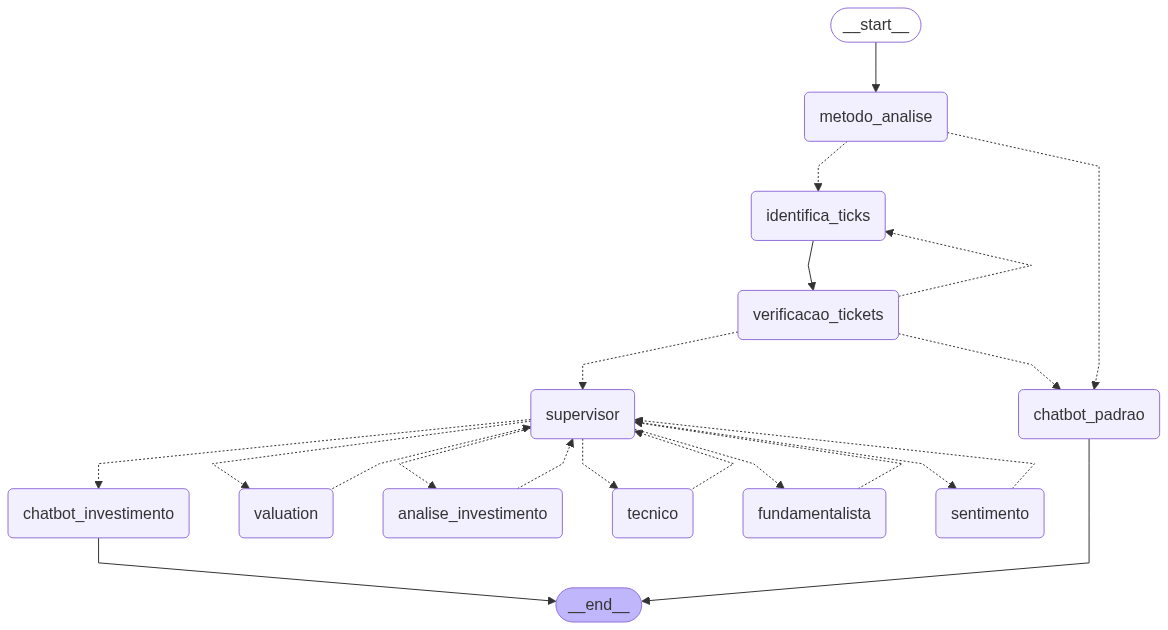

In [15]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import Image, display

try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception:
    print("Exception")
    pass

In [23]:
resposta = await graph_builder.ainvoke({"messages": "Como esta os fundamentos e o sentimento  da vale e itau, banco do brasil?"})
resposta

Entrei no identifica_metodo_analise
Entrei identificacao ticks
Entrei verificacao tickets
Entrei no supervisor
Entrei nos sentimentos comparacao
Error fetching URL: Client error '403 Forbidden' for url 'https://br.advfn.com/noticias/BOV/2025/artigo/96295593'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: The read operation timed out
Entrei no supervisor
Entrei nos fundamentos comparacao
O modelo usado e o: meta-llama/llama-4-scout-17b-16e-instruct
Entrei no supervisor
Todos os métodos de análise concluídos


{'messages': [HumanMessage(content='Como esta os fundamentos e o sentimento  da vale e itau, banco do brasil?', additional_kwargs={}, response_metadata={}, id='7468c9d1-3725-4a4c-9bd1-97b46a46d525'),
  AIMessage(content='Aqui está uma análise resumida dos fundamentos e do sentimento das ações da Vale (VALE3), Itaú (ITUB4) e Banco do Brasil (BBAS3):\n\n**Vale (VALE3):**\n\n* Fundamentos: Fortes devido ao aumento do preço do minério de ferro (US$100) e valorização das ações. No entanto, teve uma queda significativa na receita no Q4 2024 e lucro líquido negativo no mesmo período.\n* Sentimento: Misto. As ações estão subindo, mas há pressão com viés de baixa.\n\n**Itaú (ITUB4):**\n\n* Fundamentos: Consistentes, com crescimento de receita e lucro. Possui um preço-alvo elevado e recomendação de compra da BofA, mas também há sugestões de venda do BB Investimentos.\n* Sentimento: Dividido, com expectativa de resultados em 5 de agosto.\n\n**Banco do Brasil (BBAS3):**\n\n* Fundamentos: Queda sig

In [21]:
resposta = graph_builder.invoke({"messages": "Como esta os fundamentos e o sentimento  da aod, kkk, kakak?"})
resposta

Entrei no identifica_metodo_analise
Entrei identificacao ticks
Entrei verificacao tickets
Entrei identificacao ticks
Entrei verificacao tickets
Entrei identificacao ticks
Entrei verificacao tickets
As ações nao foram encontrados!
Entrei no chatbot_padrao


{'messages': [HumanMessage(content='Como esta os fundamentos e o sentimento  da aod, kkk, kakak?', additional_kwargs={}, response_metadata={}, id='cb61f209-c8fa-4710-8701-cb5f46182b14'),
  AIMessage(content='Olá! Seja bem-vindo ao nosso chatbot de investimentos!\n\nInfelizmente, não consegui encontrar informações sobre a ação "AOD". Pode ser que seja uma ação pouco conhecida ou não esteja listada em nossos bancos de dados.\n\nSe você puder me fornecer mais informações sobre a ação, como o país de origem ou a bolsa em que é negociada, posso tentar ajudar a encontrar as informações que você procura.\n\nSe você tiver alguma outra pergunta ou precisar de ajuda com algo mais, estou aqui para ajudar!\n\n**Pergunta original:** Como está os fundamentos e o sentimento da aod, kkk, kakak?\n\n**Status:** Ações não encontradas!##', additional_kwargs={}, response_metadata={}, id='ba636f4c-34de-477f-ac1f-ee436c580aaa')],
 'ticker': [],
 'method_analysis': ['fundamentalista', 'sentimento']}

In [22]:
resposta = graph_builder.invoke({"messages": "Bom dia como voce esta?"})
resposta

Entrei no identifica_metodo_analise
Entrei no chatbot_padrao


{'messages': [HumanMessage(content='Bom dia como voce esta?', additional_kwargs={}, response_metadata={}, id='14a46431-a6a0-4304-9274-7ae609a4a9fc'),
  AIMessage(content='Olá! Seja bem-vindo ao nosso chatbot de investimentos. Estou aqui para ajudá-lo com qualquer dúvida ou pergunta que você tenha sobre investimentos.\n\nO sistema informou que você não informou nenhum método de análise. Por favor, me diga qual é o seu método de análise preferido (por exemplo, fundamental, técnico, etc.) para que eu possa ajudá-lo melhor.\n\nE aqui está a pergunta que você fez: {messages}\n\nPor favor, responda para que eu possa ajudá-lo.', additional_kwargs={}, response_metadata={}, id='6087c112-0fb1-4056-8f7d-599cd4859e6d')]}